## 乳腺癌数据分析

In [1]:
import os
import pandas as pd
import numpy as np

os.chdir('/pri_exthome/zhouwg/project/Garfield')
os.getcwd()

'/pri_exthome/zhouwg/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
import numpy as np
import pandas as pd
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

/home/zhouwg/anaconda3/envs/env_gf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.4.0'

In [3]:
# read data
import scipy.sparse as sp

dataset=''
root_dir = '/pri_exthome/zhouwg/project/spatial_data/gold'
file_fold = os.path.join(root_dir, str(dataset))
adata_batch1 = sc.read_h5ad(file_fold + '/xenium_human_breast_cancer_batch1.h5ad')
adata_batch1.X = adata_batch1.layers['counts'].copy()
adata_batch1.var_names_make_unique()
adata_batch2 = sc.read_h5ad(file_fold + '/xenium_human_breast_cancer_batch2.h5ad')
adata_batch2.X = adata_batch2.layers['counts'].copy()
adata_batch2.var_names_make_unique()

# concat
adata = adata_batch1.concatenate(adata_batch2, batch_key='batch')

# Create new adata to drop all unnecessary columns
adata_new = sc.AnnData(sp.csr_matrix(
    (adata.shape[0], adata.shape[1]),
    dtype=np.float32))
adata_new.X = adata.layers['counts'].copy()
adata_new.var_names = adata.var_names
adata_new.obs_names = adata.obs_names
adata_new.obsm["spatial"] = adata.obsm["spatial"]
adata_new.obs["cell_id"] = adata.obs["cell_id"].values
adata_new.obs["batch"] = adata.obs["batch"].values
adata_new.obs["replicates"] = adata.obs["replicates"].values

# Store raw counts in adata.layers
adata_new.layers["counts"] = adata.X.copy()
adata_new

AnnData object with n_obs × n_vars = 282363 × 313
    obs: 'cell_id', 'batch', 'replicates'
    obsm: 'spatial'
    layers: 'counts'

In [4]:
adata_new.obs['replicates'].value_counts()

replicates
Rep_1    164000
Rep_2    118363
Name: count, dtype: int64

In [5]:
# Ensure adata.X is counts.
# adata.layers['counts'] = adata.X.copy()
# adata.X = adata.layers['counts'].copy()
adata.X.max()

167.0

### Integrating spatially resolved transcriptomics data using Garfield

In [6]:
# set workdir #
workdir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_xenium_human_breast'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=adata_new,
    profile='spatial',
    data_type='single-modal',
    sample_col='batch',
    weight=0.5,
    ## Preprocessing options
    graph_const_method='Squidpy', # mu_std, Radius, KNN, Squidpy
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    n_components=50,
    n_neighbors=5,
    metric='euclidean',
    svd_solver='arpack',
    # datasets
    used_pca_feat=False,
    adj_key='connectivities',
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,
    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=True,
    conv_type='GAT', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2,
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=True,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1., #
    lambda_edge_recon=1., #
    lambda_latent_adj_recon_loss=2.,
    lambda_omics_recon_mmd_loss=0.2,
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=0,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_xenium_human_breast


In [24]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2


In [25]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Using GPU: device-0
Number of training nodes: 254127
Number of validation nodes: 28236
Number of training edges: 1615698
Number of validation edges: 179521
Edge batch size: 4096
Node batch size: 256

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.8776; val_auprc_score: 0.8936; val_best_acc_score: 0.8172; val_best_f1_score: 0.8096; train_kl_reg_loss: 50.7585; train_edge_recon_loss: 1058.6235; train_gene_expr_recon_loss: 46871.5648; train_lambda_latent_adj_recon_loss: 1209.4891; train_lambda_latent_contrastive_instanceloss: 7.3723; train_lambda_latent_contrastive_clusterloss: 3.0528; train_gene_expr_mmd_loss: 17.7750; train_global_loss: 49218.6358; train_optim_loss: 49218.6358; val_kl_reg_loss: 46.5657; val_edge_recon_loss: 964.0532; val_gene_expr_recon_loss: 41828.2551; val_lambda_latent_adj_recon_loss: 353.4837; val_lambda_latent_contrastive_instanceloss: 7.0974; val_lambda_latent_contrastive_clusterloss: 2.4568; val_gene

In [26]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [27]:
# Compute latent Leiden clustering
latent_leiden_resolution = 0.5
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

12

### Visualize Garfield Latent Space

In [16]:
import re

from matplotlib import pyplot as plt
import matplotlib
matplotlib.use("Agg") #使用非交互式的后端生成图像文件

def pic(pdf):
    searchObj = re.search( r'(.*).pdf', pdf)
    png = f"{searchObj.group(1)}.png"
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, bbox_inches="tight", dpi=300)
    plt.close()

In [ ]:
# model.adata.obsm['spatial'][:, 1] *= -1  # 翻转 y 坐标 手动修正

In [4]:
model.adata

AnnData object with n_obs × n_vars = 282363 × 313
    obs: 'cell_id', 'batch', 'replicates', 'n_genes', 'latent_leiden_0.5'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'batch_colors', 'garfield_latent', 'hvg', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'feat', 'garfield_latent', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivities', 'distances', 'garfield_latent_connectivities', 'garfield_latent_distances', 'spatial_connectivities'

[<Axes: title={'center': 'batch'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'latent_leiden_0.5'}, xlabel='UMAP1', ylabel='UMAP2'>]

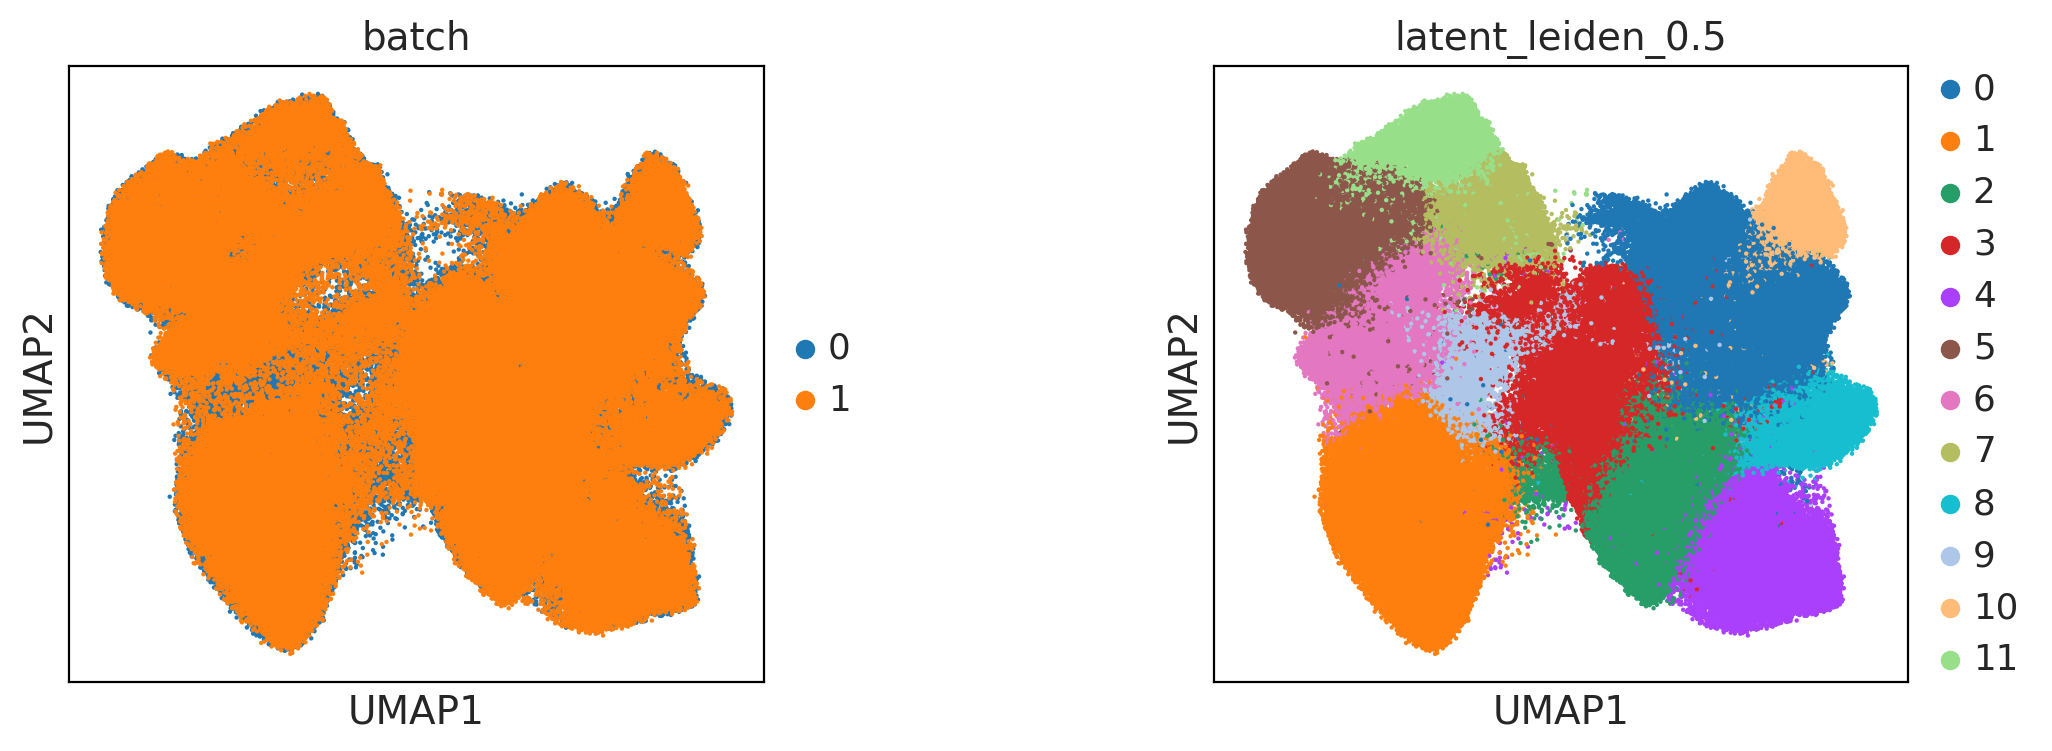

In [29]:
sc.settings.set_figure_params(dpi=100, facecolor='white')

sc.pl.umap(model.adata, color=['replicates', latent_cluster_key],
           s=10, show=False, ncols=2, wspace=0.5) # , legend_loc='on data'

In [31]:
model.adata.obs['replicates'].value_counts()

replicates
Rep_1    164000
Rep_2    118363
Name: count, dtype: int64

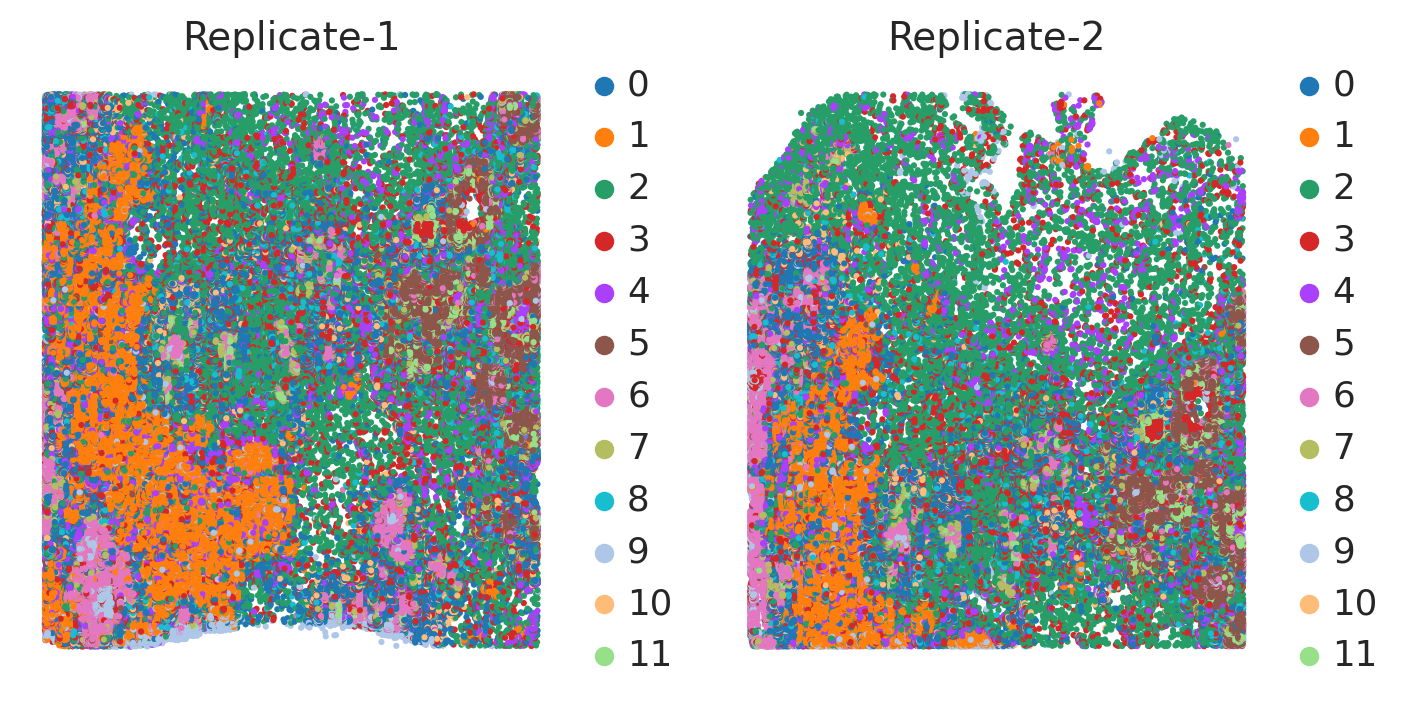

In [32]:
sc.settings.set_figure_params(dpi=100, facecolor='white')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={'wspace': 0.3, 'hspace': 0.2})

# model.adata.obsm['spatial'][:, 1] *= -1  # 翻转 y 坐标 手动修正
sc.pl.embedding(model.adata[model.adata.obs['replicates'] == 'Rep_1'],
                basis='spatial', color=latent_cluster_key,
                title='Replicate-1', s=20, show=False,
                ax=ax[0], frameon=False)
sc.pl.embedding(model.adata[model.adata.obs['replicates'] == 'Rep_2'],
                basis='spatial', color=latent_cluster_key,
                title='Replicate-2', s=20, show=False,
                ax=ax[1], frameon=False)
plt.tight_layout(w_pad=0.3)
# plt.gca().invert_yaxis()  # 翻转 y 轴
# plt.show()
# pic(os.path.join(workdir, "01.spatial_plot_niche.pdf"))

### 找 niche 差异基因 for batch1

In [63]:
def extract_top_genes_spatial(
    adata,
    workdir,
    latent_cluster_key,
    n_top_markers=5,
    output_file="all_marker_genes_spatial_data.csv",
    use_normalized=False
):
    """
    提取 AnnData 对象中所有 marker 基因的表达数据、空间位置信息和 cluster 信息，并保存为 CSV 文件。

    Parameters:
    -----------
    adata : AnnData
        包含 rank_genes_groups 和空间信息的 AnnData 对象。
    workdir : str
        输出文件的保存目录。
    latent_cluster_key : str
        cluster 信息所在的 obs 键。
    output_file : str
        保存的 CSV 文件名。
    use_normalized : bool
        如果为 True，使用标准化后的数据 (.X)；否则使用 counts 层数据。

    Returns:
    --------
    None
    """
    import os
    import pandas as pd

    # 检查 rank_genes_groups 是否存在
    if "rank_genes_groups" not in adata.uns:
        raise ValueError("The AnnData object does not contain 'rank_genes_groups' in .uns.")

    # 提取所有 marker 基因
    ranked_genes = adata.uns['rank_genes_groups']
    marker_genes = set()  # 使用集合避免重复
    clusters = ranked_genes['names'].dtype.names  # 获取所有 cluster 名
    for cluster in clusters:
        top_genes = ranked_genes['names'][cluster][:n_top_markers]  # 获取Top n 基因名
        print(f'Top markers of cluster {cluster}: {top_genes}')
        marker_genes.update(top_genes)  # 添加当前 cluster 的 marker 基因

    marker_genes = list(marker_genes)  # 转换为列表

    # 提取表达数据
    if use_normalized:
        gene_expression = adata[:, marker_genes].X  # 标准化数据
    else:
        gene_expression = adata[:, marker_genes].layers['counts']  # counts 数据

    # 提取空间位置信息
    spatial_positions = adata.obsm['spatial']

    # 提取 cluster 信息
    clusters = adata.obs[latent_cluster_key]

    # 构建最终 DataFrame
    final_dataframe = pd.DataFrame(
        gene_expression.toarray() if hasattr(gene_expression, "toarray") else gene_expression,
        columns=marker_genes,
        index=adata.obs.index
    )
    final_dataframe['x'] = spatial_positions[:, 0]  # 添加 x 坐标
    final_dataframe['y'] = spatial_positions[:, 1]  # 添加 y 坐标
    final_dataframe['cluster'] = clusters.values  # 添加 cluster 信息

    # 保存为 CSV 文件
    os.makedirs(workdir, exist_ok=True)  # 确保工作目录存在
    final_dataframe.to_csv(os.path.join(workdir, output_file))
    print(f"Data saved to {os.path.join(workdir, output_file)}")


In [61]:
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"

# batch 1
tmp = model.adata[model.adata.obs['replicates'].isin(['Rep_1']), :]
tmp.obs_names = adata_batch1.obs_names
adata_batch1.obs[latent_cluster_key] = tmp.obs[latent_cluster_key]
sc.pp.normalize_total(adata_batch1, target_sum=1e4)
sc.pp.log1p(adata_batch1)
sc.tl.rank_genes_groups(adata_batch1, latent_cluster_key, method='wilcoxon')

In [64]:
df  = sc.get.rank_genes_groups_df(adata_batch1, group=None)
df = df.sort_values(by="scores", ascending=False)
df.to_csv(os.path.join(workdir, 'diff_niches_batch1.csv'), index=0, sep='\t')

In [65]:
## output res
extract_top_genes_spatial(
    adata_batch1,
    workdir,
    latent_cluster_key,
    n_top_markers=5,
    output_file="top_genes_spatial_data_batch1.csv",
    use_normalized=True
)

Top markers of cluster 0: ['CD3E' 'TRAC' 'PTPRC' 'IL7R' 'CXCR4']
Top markers of cluster 1: ['EPCAM' 'FASN' 'FOXA1' 'KRT7' 'ABCC11']
Top markers of cluster 2: ['LUM' 'POSTN' 'CCDC80' 'MMP2' 'PDGFRB']
Top markers of cluster 3: ['FCER1G' 'FGL2' 'LYZ' 'CD4' 'CD68']
Top markers of cluster 4: ['CAV1' 'PECAM1' 'CD93' 'AQP1' 'VWF']
Top markers of cluster 5: ['CEACAM6' 'GATA3' 'TACSTD2' 'CD9' 'MLPH']
Top markers of cluster 6: ['TACSTD2' 'KRT8' 'CEACAM6' 'S100A14' 'CDH1']
Top markers of cluster 7: ['MYLK' 'KRT14' 'DST' 'KRT5' 'ACTA2']
Top markers of cluster 8: ['ITM2C' 'TENT5C' 'SLAMF7' 'MZB1' 'SEC11C']
Top markers of cluster 9: ['ERBB2' 'KRT8' 'KRT7' 'EPCAM' 'FOXA1']
Top markers of cluster 10: ['MS4A1' 'BANK1' 'CXCR4' 'SELL' 'PTPRC']
Top markers of cluster 11: ['KRT15' 'SFRP1' 'TACSTD2' 'KRT23' 'KRT6B']
Data saved to /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_xenium_human_breast/top_genes_spatial_data_batch1.csv


<Axes: title={'center': 'latent_leiden_0.5'}, xlabel='UMAP1', ylabel='UMAP2'>

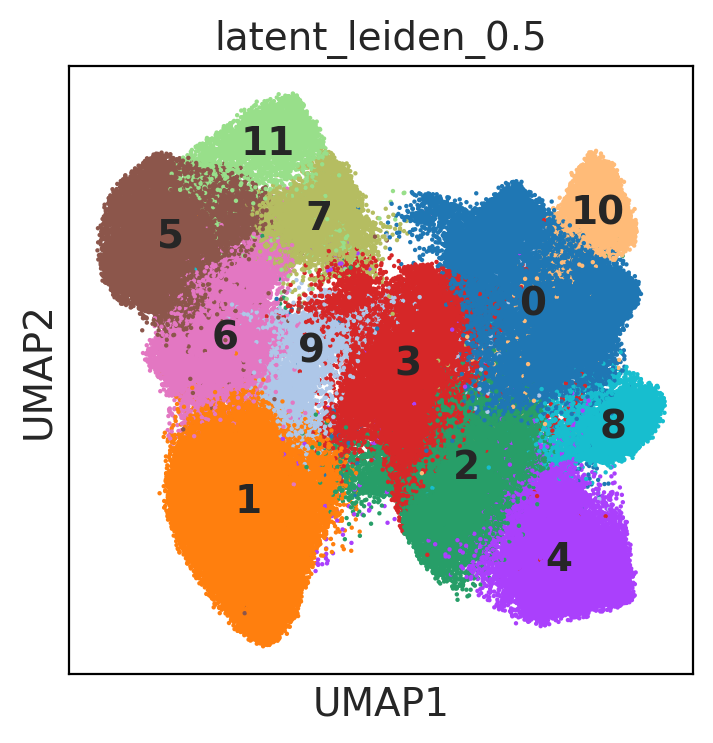

In [66]:
sc.pl.umap(model.adata[model.adata.obs['replicates'].isin(['Rep_1']), :],
           color=[latent_cluster_key],
           s=10, show=False, ncols=2, wspace=0.3, legend_loc='on data')

In [67]:
### 输出niche 和 空间位置数据供R绘图
# Extracting 'latent_leiden_0.3' and 'spatial' data
tmp = model.adata[model.adata.obs['replicates'].isin(['Rep_1']), :]
tmp.obs_names = adata_batch1.obs_names
latent_leiden_data = tmp.obs[latent_cluster_key]
spatial_data = tmp.obsm["spatial"]

# Creating a DataFrame for R visualization
output_df = pd.DataFrame({
    latent_cluster_key: latent_leiden_data,
    "spatial_X": spatial_data[:, 0],
    "spatial_Y": spatial_data[:, 1],
})

# Save to CSV
output_file = "latent_spatial_data_batch1.csv"
output_df.to_csv(os.path.join(workdir, output_file))

### 鉴定 niche 差异基因 for batch 2

In [68]:
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"

# batch 1
tmp = model.adata[model.adata.obs['replicates'].isin(['Rep_2']), :]
tmp.obs_names = adata_batch2.obs_names
adata_batch2.obs[latent_cluster_key] = tmp.obs[latent_cluster_key]
sc.pp.normalize_total(adata_batch2, target_sum=1e4)
sc.pp.log1p(adata_batch2)
sc.tl.rank_genes_groups(adata_batch2, latent_cluster_key, method='wilcoxon')

In [70]:
df  = sc.get.rank_genes_groups_df(adata_batch2, group=None)
df = df.sort_values(by="scores", ascending=False)
df.to_csv(os.path.join(workdir, 'diff_niches_batch2.csv'), index=0, sep='\t')

In [71]:
## output res
extract_top_genes_spatial(
    adata_batch2,
    workdir,
    latent_cluster_key,
    n_top_markers=5,
    output_file="top_genes_spatial_data_batch2.csv",
    use_normalized=True
)

Top markers of cluster 0: ['CD3E' 'TRAC' 'IL7R' 'PTPRC' 'CXCR4']
Top markers of cluster 1: ['EPCAM' 'FOXA1' 'FASN' 'KRT7' 'ABCC11']
Top markers of cluster 2: ['LUM' 'POSTN' 'CCDC80' 'MMP2' 'PDGFRB']
Top markers of cluster 3: ['FCER1G' 'FGL2' 'LYZ' 'CD4' 'CD68']
Top markers of cluster 4: ['CAV1' 'PECAM1' 'CD93' 'AQP1' 'VWF']
Top markers of cluster 5: ['CEACAM6' 'GATA3' 'TACSTD2' 'CD9' 'SCD']
Top markers of cluster 6: ['SERPINA3' 'TACSTD2' 'KRT8' 'CCND1' 'CEACAM6']
Top markers of cluster 7: ['MYLK' 'KRT14' 'DST' 'KRT5' 'PTN']
Top markers of cluster 8: ['TENT5C' 'ITM2C' 'SLAMF7' 'MZB1' 'SEC11C']
Top markers of cluster 9: ['ERBB2' 'KRT8' 'KRT7' 'SCD' 'FOXA1']
Top markers of cluster 10: ['MS4A1' 'BANK1' 'CXCR4' 'SELL' 'PTPRC']
Top markers of cluster 11: ['KRT15' 'TACSTD2' 'SFRP1' 'KRT23' 'KRT7']
Data saved to /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_xenium_human_breast/top_genes_spatial_data_batch2.csv


<Axes: title={'center': 'latent_leiden_0.5'}, xlabel='UMAP1', ylabel='UMAP2'>

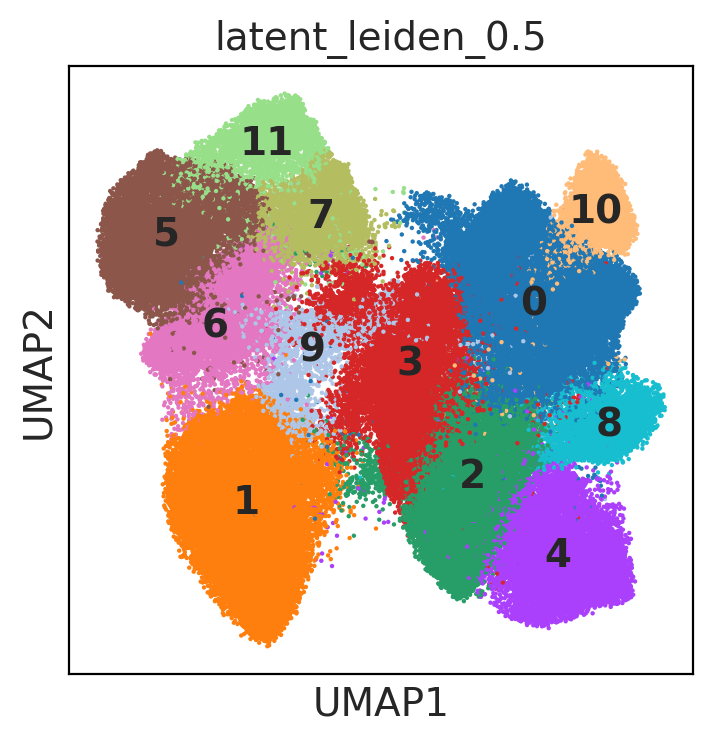

In [72]:
sc.pl.umap(model.adata[model.adata.obs['replicates'].isin(['Rep_2']), :],
           color=[latent_cluster_key],
           s=10, show=False, ncols=2, wspace=0.3, legend_loc='on data')

In [74]:
### 输出niche 和 空间位置数据供R绘图
# Extracting 'latent_leiden_0.3' and 'spatial' data
tmp = model.adata[model.adata.obs['replicates'].isin(['Rep_2']), :]
tmp.obs_names = adata_batch2.obs_names
latent_leiden_data = tmp.obs[latent_cluster_key]
spatial_data = tmp.obsm["spatial"]

# Creating a DataFrame for R visualization
output_df = pd.DataFrame({
    latent_cluster_key: latent_leiden_data,
    "spatial_X": spatial_data[:, 0],
    "spatial_Y": spatial_data[:, 1],
})

# Save to CSV
output_file = "latent_spatial_data_batch2.csv"
output_df.to_csv(os.path.join(workdir, output_file))

### 保存model 的结果

In [21]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_concat.h5ad")

Model saved successfully using pickle at /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_xenium_human_breast/model/attr.pkl


In [3]:
from Garfield.model import Garfield

workdir = f'/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_xenium_human_breast'
gf.settings.set_workdir(workdir)
model_folder_path = f"{workdir}/model"

model = Garfield.load(dir_path=model_folder_path,
              adata_file_name="adata_concat.h5ad")

Saving results in: /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_xenium_human_breast
Model loaded successfully using pickle from /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_xenium_human_breast/model/attr.pkl
AnnData object with n_obs × n_vars = 282363 × 313
    obs: 'cell_id', 'batch', 'replicates', 'n_genes', 'latent_leiden_0.5', 'latent_leiden_0.4', 'latent_leiden_0.6', 'latent_leiden_0.7', 'latent_leiden_0.8', 'Cluster'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'batch_colors', 'garfield_latent', 'hvg', 'latent_leiden_0.4', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'latent_leiden_0.6', 'latent_leiden_0.7', 'latent_leiden_0.8', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'feat', 'garfield_latent', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivitie

In [4]:
model.adata.obs_names

Index(['1-Rep_1-0', '2-Rep_1-0', '4-Rep_1-0', '5-Rep_1-0', '7-Rep_1-0',
       '8-Rep_1-0', '9-Rep_1-0', '10-Rep_1-0', '11-Rep_1-0', '12-Rep_1-0',
       ...
       '118743-Rep_2-1', '118744-Rep_2-1', '118745-Rep_2-1', '118746-Rep_2-1',
       '118747-Rep_2-1', '118748-Rep_2-1', '118749-Rep_2-1', '118750-Rep_2-1',
       '118751-Rep_2-1', '118752-Rep_2-1'],
      dtype='object', length=282363)

### 读取原作者的celltype标签

In [4]:
### 读取原作者的celltype标签
import pandas as pd

# 读取xlsx文件
root_dir = '/pri_exthome/zhouwg/project/spatial_data/bronze/xenium_human_breast_cancer'
data1 = pd.read_excel(os.path.join(root_dir, 'Cell_Barcode_Type_Matrices.xlsx'),
                     sheet_name='Xenium R1 Fig1-5 (supervised)', index_col=0)
# 生成新的行名
data1.index = [f"{name}-Rep_1-0" for name in data1.index]

data2 = pd.read_excel(os.path.join(root_dir, 'Cell_Barcode_Type_Matrices.xlsx'),
                     sheet_name='Xenium R2 Fig1-5 (supervised)', index_col=0)
# 生成新的行名
data2.index = [f"{name}-Rep_2-1" for name in data2.index]
data = pd.concat([data1, data2])

In [ ]:
model.adata.obs = model.adata.obs.join(data)
model.adata

In [7]:
model.adata.obs['Cluster'].value_counts()

Cluster
Stromal                    80059
Invasive_Tumor             50133
DCIS_2                     21707
DCIS_1                     20094
Macrophages_1              19226
Endothelial                15630
CD4+_T_Cells               14393
Myoepi_ACTA2+              13140
CD8+_T_Cells               11888
B_Cells                     8779
Unlabeled                   7869
Prolif_Invasive_Tumor       5626
Myoepi_KRT15+               5507
Macrophages_2               3202
Perivascular-Like           1396
Stromal_&_T_Cell_Hybrid     1151
IRF7+_DCs                    894
T_Cell_&_Tumor_Hybrid        837
LAMP3+_DCs                   504
Mast_Cells                   328
Name: count, dtype: int64

<Axes: title={'center': 'Cluster'}, xlabel='UMAP1', ylabel='UMAP2'>

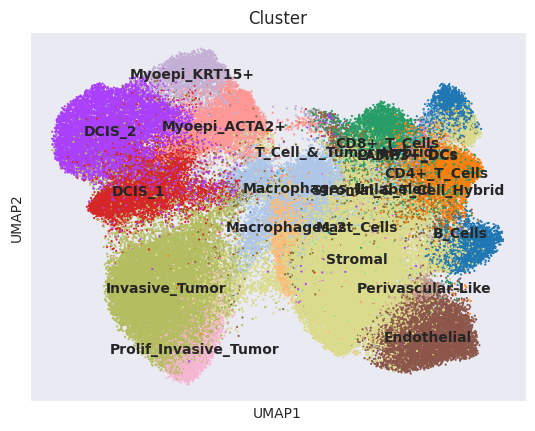

In [7]:
sc.pl.umap(model.adata[model.adata.obs['replicates'].isin(['Rep_2']), :],
           color=['Cluster'],
           s=10, show=False, ncols=2, wspace=0.3, legend_loc='on data')

In [4]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from tqdm import trange
from scipy.spatial import *
from sklearn.preprocessing import *

from sklearn.metrics import *
from scipy.spatial.distance import *

def CHAOS_score(X, pred_labels):
    """
    Calculate the CHAOS score for a given set of spatial coordinates and predicted labels.

    param: X - spatial coordinates
    param: pred_labels - predicted labels

    return: CHAOS score
    """
    # Standardize the spatial coordinates
    X = StandardScaler().fit_transform(X)

    # Get the unique cluster labels
    cluster_labels = np.unique(pred_labels)

    # Initialize the distance value and count
    dist_val = 0.
    count = 0

    # Iterate through each cluster
    for k in cluster_labels:
        # Get the spatial coordinates for the current cluster
        cluster_coords = X[pred_labels == k, :]

        # Check if there are at least 2 spatial coordinates in the cluster
        if len(cluster_coords) <= 2:
            continue
        else:
            count += len(cluster_coords)

        # Calculate the distance to the nearest neighbor for each spatial coordinate in the cluster
        nbrs = NearestNeighbors(n_neighbors=1).fit(cluster_coords)
        distances, _ = nbrs.kneighbors()

        # Sum the distances
        dist_val = dist_val + np.sum(distances)

    # Calculate the CHAOS score
    return dist_val / count

In [5]:
import pandas as pd

# Define a function to compute CHAOS score for a range of resolutions
def compute_chaos_scores(adata, resolutions, latent_key="garfield_latent"):
    results = []
    for resolution in resolutions:
        latent_cluster_key = f"latent_leiden_{resolution}"

        # Perform Leiden clustering
        sc.tl.leiden(adata=adata,
                      resolution=resolution,
                      key_added=latent_cluster_key,
                      neighbors_key=latent_key)

        # Compute CHAOS score
        X = adata.obsm['spatial']
        pred_labels = adata.obs[latent_cluster_key].values
        chaos = CHAOS_score(X=X, pred_labels=pred_labels)

        # Store results
        results.append({"Resolution": resolution, "N_niches": len(model.adata.obs[latent_cluster_key].unique()),"CHAOS_Score": chaos})

    # Convert results to a DataFrame
    df_results = pd.DataFrame(results)
    return df_results

# Define a list of resolutions
resolutions = [0.4, 0.5, 0.6, 0.7, 0.8]

# Call the function with your adata object and resolutions
# Assuming `model.adata` is the AnnData object used
chaos_results_df = compute_chaos_scores(adata=model.adata, resolutions=resolutions)

# Save the results for R visualization
chaos_results_df.to_csv(os.path.join(workdir, "chaos_results_concat.csv"), index=False)

In [6]:
chaos_results_df

,Resolution,N_niches,CHAOS_Score
0,0.4,10,0.007032
1,0.5,12,0.007249
2,0.6,11,0.007217
3,0.7,15,0.007806
4,0.8,14,0.007747


In [8]:
model.adata

AnnData object with n_obs × n_vars = 282363 × 313
    obs: 'cell_id', 'batch', 'replicates', 'n_genes', 'latent_leiden_0.5', 'latent_leiden_0.4', 'latent_leiden_0.6', 'latent_leiden_0.7', 'latent_leiden_0.8'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'batch_colors', 'garfield_latent', 'hvg', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'log1p', 'neighbors', 'pca', 'umap', 'latent_leiden_0.4', 'latent_leiden_0.6', 'latent_leiden_0.7', 'latent_leiden_0.8'
    obsm: 'X_pca', 'X_umap', 'feat', 'garfield_latent', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivities', 'distances', 'garfield_latent_connectivities', 'garfield_latent_distances', 'spatial_connectivities'

<Axes: title={'center': 'latent_leiden_0.8'}, xlabel='UMAP1', ylabel='UMAP2'>

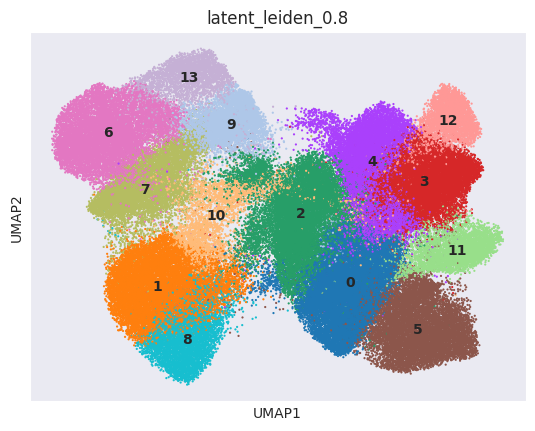

In [9]:
latent_cluster_key = 'latent_leiden_0.8'
sc.pl.umap(model.adata[model.adata.obs['replicates'].isin(['Rep_2']), :],
           color=[latent_cluster_key],
           s=10, show=False, ncols=2, wspace=0.3, legend_loc='on data')

In [10]:
### 输出niche 和 空间位置数据供R绘图
# Extracting 'latent_leiden_0.3' and 'spatial' data
dataset_name = 'xenium_human_breast'

visua_type = latent_cluster_key
latent_leiden_data = model.adata.obs[visua_type] # latent_cluster_key
spatial_data = model.adata.obsm["spatial"]

# Creating a DataFrame for R visualization
output_df = pd.DataFrame({
    visua_type: latent_leiden_data,
    "spatial_X": spatial_data[:, 0],
    "spatial_Y": spatial_data[:, 1],
})

# Save to CSV
output_file = f"latent_spatial_data_niches_{dataset_name}.csv"
output_df.to_csv(os.path.join(workdir, output_file))

In [11]:
### 输出niche 和 UMAP位置数据供R绘图
# Extracting 'latent_leiden_0.3' and 'spatial' data
visua_type = latent_cluster_key
latent_leiden_data = model.adata.obs[visua_type] # latent_cluster_key
spatial_data = model.adata.obsm["X_umap"]

# Creating a DataFrame for R visualization
output_df = pd.DataFrame({
    visua_type: latent_leiden_data,
    "umap_1": spatial_data[:, 0],
    "umap_2": spatial_data[:, 1],
})

# Save to CSV
output_file = f"latent_umap_data_niches_{dataset_name}.csv"
output_df.to_csv(os.path.join(workdir, output_file))

In [22]:
### 输出 cell_type 和 空间位置数据供R绘图
# Extracting 'latent_leiden_0.3' and 'spatial' data
dataset_name = 'xenium_human_breast'

visua_type = 'Cluster'
latent_leiden_data = model.adata.obs[visua_type] # latent_cluster_key
spatial_data = model.adata.obsm["spatial"]

# Creating a DataFrame for R visualization
output_df = pd.DataFrame({
    visua_type: latent_leiden_data,
    "spatial_X": spatial_data[:, 0],
    "spatial_Y": spatial_data[:, 1],
})

# Save to CSV
output_file = f"latent_spatial_data_cell_type_{dataset_name}.csv"
output_df.to_csv(os.path.join(workdir, output_file))

In [24]:
### 输出 cell_type 和 UMAP位置数据供R绘图
visua_type = 'Cluster'
latent_leiden_data = model.adata.obs[visua_type] # latent_cluster_key
spatial_data = model.adata.obsm["X_umap"]

# Creating a DataFrame for R visualization
output_df = pd.DataFrame({
    visua_type: latent_leiden_data,
    "umap_1": spatial_data[:, 0],
    "umap_2": spatial_data[:, 1],
})

# Save to CSV
output_file = f"latent_umap_data_cell_type_{dataset_name}.csv"
output_df.to_csv(os.path.join(workdir, output_file))

In [12]:
### 输出replicates 和 UMAP位置数据供R绘图
# Extracting 'latent_leiden_0.3' and 'spatial' data
visua_type = 'replicates'
latent_leiden_data = model.adata.obs[visua_type] # latent_cluster_key
spatial_data = model.adata.obsm["X_umap"]

# Creating a DataFrame for R visualization
output_df = pd.DataFrame({
    visua_type: latent_leiden_data,
    "umap_1": spatial_data[:, 0],
    "umap_2": spatial_data[:, 1],
})

# Save to CSV
output_file = f"latent_umap_data_repli_{dataset_name}.csv"
output_df.to_csv(os.path.join(workdir, output_file))

### dendrogram analysis

In [ ]:
sc.tl.dendrogram(adata=model.adata,
                 use_rep="garfield_latent",
                 linkage_method="single",
                 groupby="latent_leiden_0.8")
# plt.show()
# pic(os.path.join(res_dir, "00.dendrogram_garfield_latent.pdf"))

In [83]:
sc.settings.set_figure_params(dpi=100, facecolor='white')

fig, (ax) = plt.subplots(1, 1, figsize=(3, 8))
sc.pl.dendrogram(
    adata=model.adata,
    groupby="latent_leiden_0.8",
    orientation="left",
    ax=ax)

res_dir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_xenium_human_breast'
pic(os.path.join(res_dir, "01.dendrogram_garfield_latent.pdf"))

### 在空间位置上可视化多种细胞类型的分布

In [8]:
# Neighborhood composition
from sklearn.neighbors import NearestNeighbors
n=25
adata = model.adata.copy()
batch_key = 'replicates'
celltye_key = 'Cluster'

# compute n neighbours per cell type
knn = {}
cell_counts = {}
for b in adata.obs[batch_key].unique():
    X = adata[adata.obs[batch_key]==b].obsm['spatial']
    celltypes = adata[adata.obs[batch_key]==b].obs[celltye_key].astype(str).values.astype('<U22')
    cellnames = adata[adata.obs[batch_key]==b].obs_names

    knn[b] = NearestNeighbors(n_neighbors=n)
    knn[b].fit(X)
    knn[b] = knn[b].kneighbors(X, return_distance=False)
    knn[b] = celltypes[knn[b]]

    for i in range(len(cellnames)):
        unique, counts = np.unique(knn[b][i,:], return_counts=True)
        cell_counts[cellnames[i]] = dict(zip(unique, counts))

adata.obsm[f'k{n}_neighbours_celltype'] = pd.DataFrame(cell_counts).T.fillna(0)

In [9]:
latent_cluster_key = 'latent_leiden_0.8'
adata.obs['leidenOrd'] = adata.obs[latent_cluster_key]

In [10]:
if not 'cluster_grups' in adata.uns:
    adata.uns['cluster_groups'] = {}

adata.uns['cluster_groups'][f"leidenOrd"] = {
    'invasive_tumor_clusters': ['1', '8'],
    'in_situ_tumor_clusters': ['6', '7'],
    'Myoepi_clusters': ['9', '13'],
    'stroma_clusters': ['0', '5'],
    'macrophage_clusters': ['2'],
    'lymphoid_clusters': ['3', '4', '10', '11', '12']
}

/tmp/ipykernel_649360/4009144604.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt[leiden_col_key] = dt[leiden_col_key].cat.remove_unused_categories()


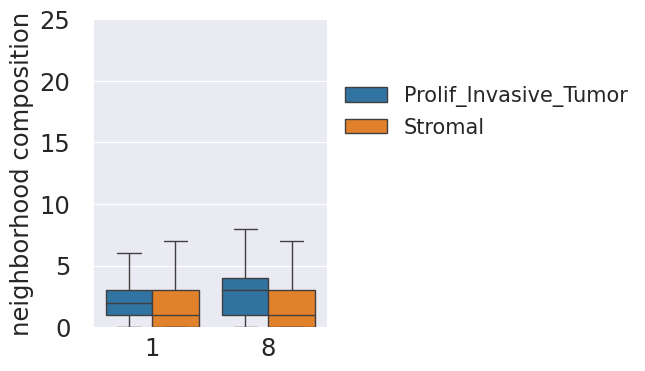

/tmp/ipykernel_649360/4009144604.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt[leiden_col_key] = dt[leiden_col_key].cat.remove_unused_categories()


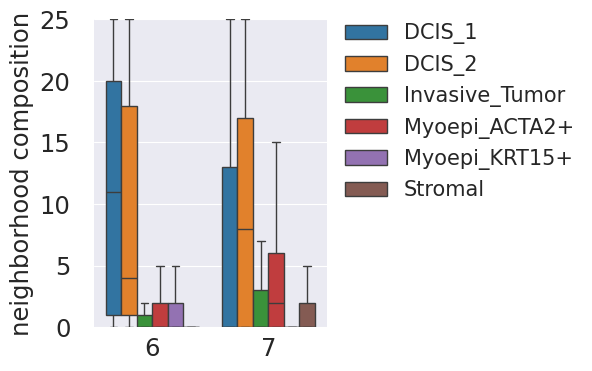

/tmp/ipykernel_649360/4009144604.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt[leiden_col_key] = dt[leiden_col_key].cat.remove_unused_categories()


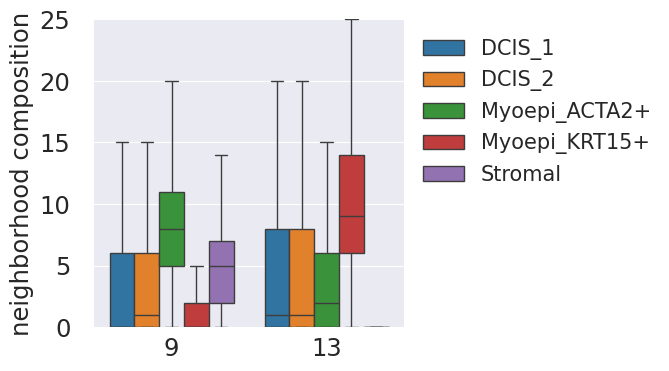

/tmp/ipykernel_649360/4009144604.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt[leiden_col_key] = dt[leiden_col_key].cat.remove_unused_categories()


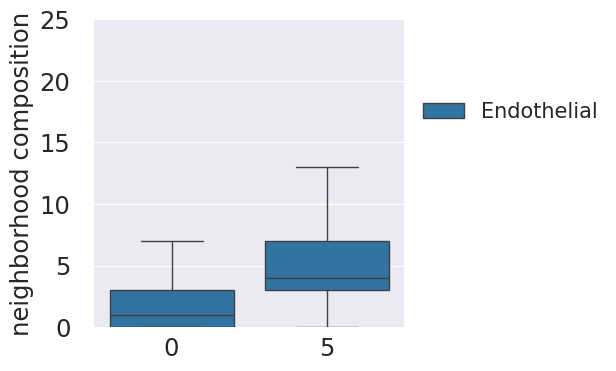

/tmp/ipykernel_649360/4009144604.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt[leiden_col_key] = dt[leiden_col_key].cat.remove_unused_categories()


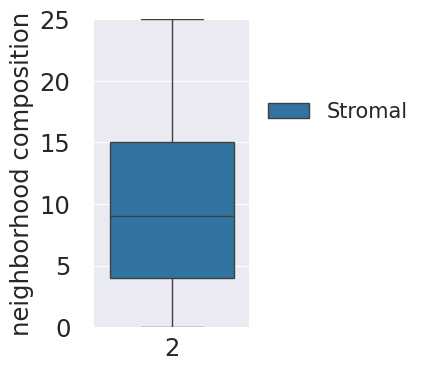

/tmp/ipykernel_649360/4009144604.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt[leiden_col_key] = dt[leiden_col_key].cat.remove_unused_categories()


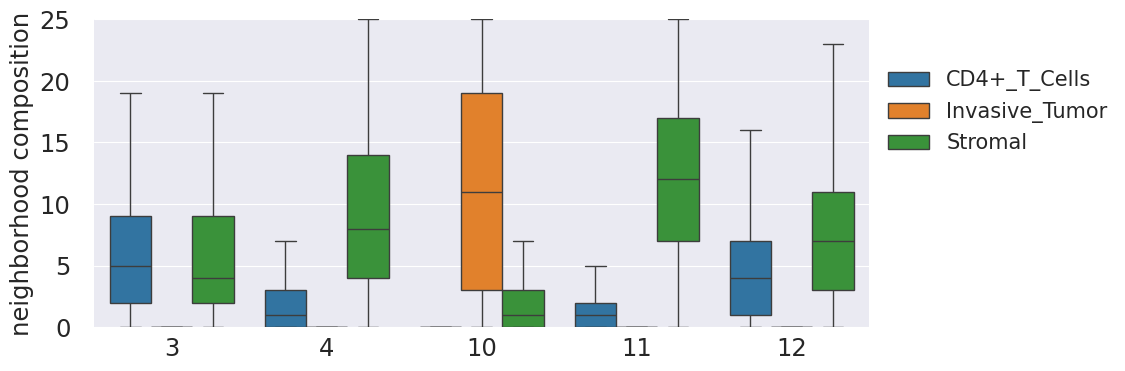

In [71]:
from matplotlib import rcParams
import seaborn as sns
import matplotlib.pyplot as plt
figure_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_xenium_human_breast'
leiden_col_key='leidenOrd'

for structure, groups in adata.uns['cluster_groups'][leiden_col_key].items():
    # format for plotting and keep only those with an interesting number
    dt = adata.obsm[f'k{n}_neighbours_celltype']
    dt[leiden_col_key] = adata.obs[leiden_col_key]
    dt = dt.loc[dt[leiden_col_key].isin(groups),:]
    dt[leiden_col_key] = dt[leiden_col_key].cat.remove_unused_categories()
    dt = dt.reset_index()
    dt = pd.melt(dt, id_vars=['index',leiden_col_key], value_name=f'n NN/{n}', var_name='cell type')
    dt['cell type'] = pd.Categorical(dt['cell type'],
                                     categories=adata.obs[celltye_key].cat.categories)
    if structure in ['in_situ_tumor_clusters','invasive_tumor_clusters']:
        include = (dt.groupby(['cell type',leiden_col_key])[f'n NN/{n}'].mean().groupby(['cell type']).max() > n*0.05) & (dt.groupby(['cell type',leiden_col_key])[f'n NN/{n}'].mean().groupby(['cell type']).max() < n*0.6)
        rcParams['figure.figsize'] = (len(groups)*1.5, 4)
    else:
        include = (dt.groupby(['cell type',leiden_col_key])[f'n NN/{n}'].mean().groupby(['cell type']).max() > n*0.15) & (dt.groupby(['cell type',leiden_col_key])[f'n NN/{n}'].mean().groupby(['cell type']).max() < n*0.6)
        rcParams['figure.figsize'] = (len(groups)*2, 4)
    dt = dt[dt['cell type'].isin(include[include].index.values)]
    dt['cell type'] = dt['cell type'].cat.remove_unused_categories()

    # plot
    sns.boxplot(data=dt, x=leiden_col_key, y=f'n NN/{n}', hue='cell type',
                #palette=adata.uns[f'{celltye_key}_colors'][include.values],
                showfliers = False).set(title='')
    plt.ylim((0, 25))
    plt.xticks(rotation=0)
    plt.xlabel("", fontsize=17.5)
    plt.ylabel(f'neighborhood composition', fontsize=17.5)
    plt.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.7), fontsize=15)
    plt.tick_params(bottom=False, labelsize=17.5)
    sns.despine(offset=10, trim=True, bottom=True)
    plt.savefig(f"{figure_path}/spatial_{structure}.pdf", bbox_inches="tight", format='pdf')
    plt.show()
rcParams['figure.figsize'] = (4, 3)

In [24]:
## 归一化
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

## Rep_1
n = 25  # 每个细胞计算的邻居数
adata = model.adata.copy()  # 复制 AnnData 对象
adata = adata[adata.obs[batch_key] == 'Rep_1']
batch_key = 'replicates'  # 用于区分批次的列
celltye_key = 'Cluster'   # 用于表示细胞类型的列

# 创建存储邻接类型和其丰度的字典
knn = {}
cell_counts = {}

for b in adata.obs[batch_key].unique():
    # 获取当前批次的空间坐标和细胞类型
    X = adata[adata.obs[batch_key] == b].obsm['spatial']
    celltypes = adata[adata.obs[batch_key] == b].obs[celltye_key].astype(str).values.astype('<U22')
    cellnames = adata[adata.obs[batch_key] == b].obs_names

    # 计算每个细胞的 n 个最近邻
    knn[b] = NearestNeighbors(n_neighbors=n)
    knn[b].fit(X)
    knn[b] = knn[b].kneighbors(X, return_distance=False)  # 只获取最近邻的索引
    knn[b] = celltypes[knn[b]]  # 根据邻接的索引获取邻接的细胞类型

    for i in range(len(cellnames)):
        # 统计邻接细胞类型的计数
        unique, counts = np.unique(knn[b][i, :], return_counts=True)
        cell_counts[cellnames[i]] = dict(zip(unique, counts))

        # 获取该细胞的邻接类型的总数
        total_neighbors = sum(counts)

        # 如果邻接细胞类型计数不为0，归一化每个细胞类型的丰度
        if total_neighbors > 0:
            normalized_counts = counts / total_neighbors  # 归一化（得到0-1之间的值）
            cell_counts[cellnames[i]] = dict(zip(unique, normalized_counts))  # 更新为归一化后的丰度

# 将邻接的归一化细胞类型丰度保存到 `AnnData` 对象的 `obsm` 中
adata.obsm[f'k{n}_neighbours_celltype_normalized'] = pd.DataFrame(cell_counts).T.fillna(0)

In [13]:
adata.obsm[f'k{n}_neighbours_celltype_normalized'].columns

Index(['DCIS_2', 'Invasive_Tumor', 'Macrophages_1', 'Unlabeled', 'DCIS_1',
       'Stromal', 'Myoepi_ACTA2+', 'CD8+_T_Cells', 'Endothelial',
       'Prolif_Invasive_Tumor', 'T_Cell_&_Tumor_Hybrid', 'B_Cells',
       'CD4+_T_Cells', 'Mast_Cells', 'Stromal_&_T_Cell_Hybri',
       'Perivascular-Like', 'IRF7+_DCs', 'Macrophages_2', 'LAMP3+_DCs',
       'Myoepi_KRT15+'],
      dtype='object')

In [25]:
# 确保 select_celltype 和 prop.columns 中的细胞类型是完全匹配的
from matplotlib import rcParams
sc.settings.set_figure_params(dpi=100, facecolor='white')

select_celltype = ['CD8+_T_Cells', 'CD4+_T_Cells', 'Invasive_Tumor', 'IRF7+_DCs']

# 获取归一化的邻居组成数据
prop = adata.obsm[f'k{n}_neighbours_celltype_normalized']
# 使用 .loc 筛选需要的细胞类型
prop_sub = prop.loc[:, prop.columns.isin(select_celltype)]

from Garfield.plot import plot_multi_patterns_spatial
rcParams['axes.grid'] = False

fig = plot_multi_patterns_spatial(
    adata,
    prop_sub,
    basis="spatial",
    display_zeros=True,
    spot_size=2)
res_dir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_xenium_human_breast'
pic(os.path.join(res_dir, "02.rep1_plot_multi_patterns_spatial.pdf"))

/pri_exthome/zhouwg/project/Garfield/Garfield/plot/spatial_plot.py:372: RuntimeWarning: invalid value encountered in divide
  weighted_colors_ryb = (colors_ryb * kernel_weights).sum(


In [26]:
## 归一化
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

## Rep_2
n = 25  # 每个细胞计算的邻居数
adata = model.adata.copy()  # 复制 AnnData 对象
adata = adata[adata.obs[batch_key] == 'Rep_2']
batch_key = 'replicates'  # 用于区分批次的列
celltye_key = 'Cluster'   # 用于表示细胞类型的列

# 创建存储邻接类型和其丰度的字典
knn = {}
cell_counts = {}

for b in adata.obs[batch_key].unique():
    # 获取当前批次的空间坐标和细胞类型
    X = adata[adata.obs[batch_key] == b].obsm['spatial']
    celltypes = adata[adata.obs[batch_key] == b].obs[celltye_key].astype(str).values.astype('<U22')
    cellnames = adata[adata.obs[batch_key] == b].obs_names

    # 计算每个细胞的 n 个最近邻
    knn[b] = NearestNeighbors(n_neighbors=n)
    knn[b].fit(X)
    knn[b] = knn[b].kneighbors(X, return_distance=False)  # 只获取最近邻的索引
    knn[b] = celltypes[knn[b]]  # 根据邻接的索引获取邻接的细胞类型

    for i in range(len(cellnames)):
        # 统计邻接细胞类型的计数
        unique, counts = np.unique(knn[b][i, :], return_counts=True)
        cell_counts[cellnames[i]] = dict(zip(unique, counts))

        # 获取该细胞的邻接类型的总数
        total_neighbors = sum(counts)

        # 如果邻接细胞类型计数不为0，归一化每个细胞类型的丰度
        if total_neighbors > 0:
            normalized_counts = counts / total_neighbors  # 归一化（得到0-1之间的值）
            cell_counts[cellnames[i]] = dict(zip(unique, normalized_counts))  # 更新为归一化后的丰度

# 将邻接的归一化细胞类型丰度保存到 `AnnData` 对象的 `obsm` 中
adata.obsm[f'k{n}_neighbours_celltype_normalized'] = pd.DataFrame(cell_counts).T.fillna(0)

In [27]:
# 确保 select_celltype 和 prop.columns 中的细胞类型是完全匹配的
select_celltype = ['CD8+_T_Cells', 'CD4+_T_Cells', 'Invasive_Tumor', 'IRF7+_DCs']

# 获取归一化的邻居组成数据
prop = adata.obsm[f'k{n}_neighbours_celltype_normalized']
# 使用 .loc 筛选需要的细胞类型
prop_sub = prop.loc[:, prop.columns.isin(select_celltype)]
# 重新排列列顺序
prop_sub = prop_sub[select_celltype]

from Garfield.plot import plot_multi_patterns_spatial
rcParams['axes.grid'] = False

fig = plot_multi_patterns_spatial(
    adata,
    prop_sub,
    basis="spatial",
    display_zeros=True,
    spot_size=5)
pic(os.path.join(res_dir, "02.rep2_plot_multi_patterns_spatial.pdf"))

/pri_exthome/zhouwg/project/Garfield/Garfield/plot/spatial_plot.py:372: RuntimeWarning: invalid value encountered in divide
  weighted_colors_ryb = (colors_ryb * kernel_weights).sum(


In [100]:
## 提取特定的batch数据集
import math
import matplotlib.pyplot as plt

latent_cluster_key = 'latent_leiden_0.8'
batch = 'Rep_1'
colors = [
    "#FEE2DDFF", "#C40003FF", "#FEF79EFF", "#0055AAFF",
    "#00C19BFF", "#007ED3FF", "#B2DF8AFF", "#FFACAAFF",
    "#F51E02FF", "#CAB2D6FF", "#894FC6FF", "#b8396b",
    "#ffd1d7", "#BA6222FF"
]

# 筛选出属于指定 batch 的数据子集
adata_batch = model.adata[model.adata.obs['replicates'] == batch].copy()

# 绘制 UMAP 图
sc.pl.umap(adata_batch, color=[latent_cluster_key],
           s=10, show=False, ncols=2, wspace=0.3,
           palette=colors)

# cluster_list = list(adata_batch.obs[latent_cluster_key].unique()) # ['0', '1', '3']
categories = list(adata_batch.obs[latent_cluster_key].unique())
 # 自定义排序函数：提取每个元素中的数字部分
def extract_number(item):
    # 正则表达式提取数字部分
    match = re.search(r'(\d+)', item)
    if match:
        return int(match.group(1))
    return float('inf')  # 如果没有找到数字，就放到最后

# 按照数字部分排序
cluster_list = sorted(categories, key=extract_number)

highlight_color = adata_batch.uns[f'{latent_cluster_key}_colors']
default_color = 'lightgray'  # 为其他细胞设置灰色
fig, ax_list = plt.subplots(
    2, math.ceil(len(cluster_list) / 2), figsize=(2 * len(cluster_list), 8)
)
ax_list = ax_list.flatten()  # 展平以便在循环中逐一使用

tmp = adata_batch.copy()
for cluster, ax in zip(cluster_list, ax_list):
    # 设置所有细胞颜色为灰色
    tmp.obs['temp_color'] = default_color
    # 将特定 cluster 设置为高亮颜色
    cluster_cells = tmp.obs[latent_cluster_key] == cluster
    cluster_index = cluster_list.index(cluster)
    tmp.obs.loc[cluster_cells, 'temp_color'] = highlight_color[cluster_index]

    # 绘制空间图
    sc.pl.embedding(
        tmp,
        basis='spatial',
        color='temp_color',
        palette=[highlight_color[cluster_index], default_color],
        ax=ax,
        show=False,
        s=20,
        title=f"Niche {cluster}",
        legend_loc=None
    )

plt.tight_layout(w_pad=0.3)
# plt.show()
pic(os.path.join(res_dir, "02.rep1_spatial_plot_each_niche.pdf"))

In [101]:
## 提取特定的batch数据集
import math
import matplotlib.pyplot as plt

latent_cluster_key = 'latent_leiden_0.8'
batch = 'Rep_2'
colors = [
    "#FEE2DDFF", "#C40003FF", "#FEF79EFF", "#0055AAFF",
    "#00C19BFF", "#007ED3FF", "#B2DF8AFF", "#FFACAAFF",
    "#F51E02FF", "#CAB2D6FF", "#894FC6FF", "#b8396b",
    "#ffd1d7", "#BA6222FF"
]

# 筛选出属于指定 batch 的数据子集
adata_batch = model.adata[model.adata.obs['replicates'] == batch].copy()

# 绘制 UMAP 图
sc.pl.umap(adata_batch, color=[latent_cluster_key],
           s=10, show=False, ncols=2, wspace=0.3,
           palette=colors)

# cluster_list = list(adata_batch.obs[latent_cluster_key].unique()) # ['0', '1', '3']
categories = list(adata_batch.obs[latent_cluster_key].unique())
 # 自定义排序函数：提取每个元素中的数字部分
def extract_number(item):
    # 正则表达式提取数字部分
    match = re.search(r'(\d+)', item)
    if match:
        return int(match.group(1))
    return float('inf')  # 如果没有找到数字，就放到最后

# 按照数字部分排序
cluster_list = sorted(categories, key=extract_number)

highlight_color = adata_batch.uns[f'{latent_cluster_key}_colors']
default_color = 'lightgray'  # 为其他细胞设置灰色
fig, ax_list = plt.subplots(
    2, math.ceil(len(cluster_list) / 2), figsize=(2 * len(cluster_list), 8)
)
ax_list = ax_list.flatten()  # 展平以便在循环中逐一使用

tmp = adata_batch.copy()
for cluster, ax in zip(cluster_list, ax_list):
    # 设置所有细胞颜色为灰色
    tmp.obs['temp_color'] = default_color
    # 将特定 cluster 设置为高亮颜色
    cluster_cells = tmp.obs[latent_cluster_key] == cluster
    cluster_index = cluster_list.index(cluster)
    tmp.obs.loc[cluster_cells, 'temp_color'] = highlight_color[cluster_index]

    # 绘制空间图
    sc.pl.embedding(
        tmp,
        basis='spatial',
        color='temp_color',
        palette=[highlight_color[cluster_index], default_color],
        ax=ax,
        show=False,
        s=20,
        title=f"Niche {cluster}",
        legend_loc=None
    )

plt.tight_layout(w_pad=0.3)
# plt.show()
pic(os.path.join(res_dir, "02.rep2_spatial_plot_each_niche.pdf"))

### Niche差异基因富集分析

In [7]:
model.adata#.X.max()

AnnData object with n_obs × n_vars = 282363 × 313
    obs: 'cell_id', 'batch', 'replicates', 'n_genes', 'latent_leiden_0.5', 'latent_leiden_0.4', 'latent_leiden_0.6', 'latent_leiden_0.7', 'latent_leiden_0.8', 'Cluster'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'batch_colors', 'garfield_latent', 'hvg', 'latent_leiden_0.4', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'latent_leiden_0.6', 'latent_leiden_0.7', 'latent_leiden_0.8', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'feat', 'garfield_latent', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivities', 'distances', 'garfield_latent_connectivities', 'garfield_latent_distances', 'spatial_connectivities'

In [4]:
from Garfield.analysis import calc_marker_stats,filter_marker_stats,aggregate_top_markers

niche_key = 'latent_leiden_0.8'
frac_df, mean_df, stats_df = calc_marker_stats(model.adata,
                                               groupby=niche_key,
                                               use_raw=False)

In [5]:
stats_df

,top_frac_group,top_frac,frac_diff,max_frac_diff,top_mean_group,top_mean,mean_diff,max_mean_diff
ABCC11,1,0.869766,0.007544,0.157935,1,3.521927,0.071097,1.355779
ACTA2,9,0.939741,0.107596,0.163037,9,6.316395,1.214933,2.976830
ACTG2,9,0.867411,0.067928,0.076796,9,4.318589,1.891008,2.228038
ADAM9,8,0.819603,0.058651,0.076345,13,2.485815,0.139455,0.664871
ADGRE5,4,0.454260,0.082680,0.110420,4,0.691332,0.165254,0.214874
...,...,...,...,...,...,...,...,...
VWF,5,0.757639,0.547358,0.610715,5,4.454386,4.128945,4.222419
WARS,8,0.574225,0.060215,0.075467,8,0.984080,0.053028,0.078355
ZEB1,5,0.609015,0.013744,0.268557,5,1.296380,0.042959,0.755853
ZEB2,2,0.856505,0.009649,0.046358,2,3.227237,0.311827,0.312173


In [6]:
filtered_stats_df = filter_marker_stats(stats_df, use_raw=False)
filtered_stats_df

,top_frac_group,top_frac,frac_diff,max_frac_diff,top_mean_group,top_mean,mean_diff,max_mean_diff
LUM,0,0.996524,0.089779,0.157525,0,23.035275,14.295960,15.823607
POSTN,0,0.981910,0.173626,0.211133,0,19.802172,13.911303,13.971071
CXCL12,0,0.921449,0.116930,0.134596,0,10.290223,6.076733,6.093116
CCDC80,0,0.942203,0.189961,0.316198,0,9.114605,5.254186,6.262940
MMP2,0,0.900898,0.343140,0.374988,0,5.896849,4.210658,4.382273
...,...,...,...,...,...,...,...,...
CDC42EP1,13,0.340711,0.144270,0.214085,13,0.482519,0.256816,0.341248
C5orf46,13,0.258892,0.074330,0.228083,13,0.470308,0.179277,0.432408
LIF,13,0.137994,0.092833,0.113404,13,0.231109,0.167806,0.200844
TUBB2B,13,0.330179,0.064643,0.079973,13,0.487557,0.148570,0.178164


In [7]:
final_markers = aggregate_top_markers(model.adata, filtered_stats_df,
                      groupby=niche_key, n_genes=100, use_raw=False)
final_markers

,genes,cluster,top_frac,frac_diff,max_frac_diff,top_mean_group,top_mean,mean_diff,max_mean_diff,logfoldchanges,pvals,pvals_adj
0,LUM,0,0.996524,0.089779,0.157525,0,23.035275,14.295960,15.823607,28.016331,0.000000e+00,0.000000e+00
1,POSTN,0,0.981910,0.173626,0.211133,0,19.802172,13.911303,13.971071,24.424164,0.000000e+00,0.000000e+00
2,CXCL12,0,0.921449,0.116930,0.134596,0,10.290223,6.076733,6.093116,12.798749,0.000000e+00,0.000000e+00
3,CCDC80,0,0.942203,0.189961,0.316198,0,9.114605,5.254186,6.262940,11.820065,0.000000e+00,0.000000e+00
4,MMP2,0,0.900898,0.343140,0.374988,0,5.896849,4.210658,4.382273,8.532184,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...
210,CDC42EP1,13,0.340711,0.144270,0.214085,13,0.482519,0.256816,0.341248,2.660414,1.326514e-307,3.204500e-307
211,C5orf46,13,0.258892,0.074330,0.228083,13,0.470308,0.179277,0.432408,4.358301,5.843159e-235,1.243841e-234
212,LIF,13,0.137994,0.092833,0.113404,13,0.231109,0.167806,0.200844,3.344476,3.511281e-101,5.066613e-101
213,TUBB2B,13,0.330179,0.064643,0.079973,13,0.487557,0.148570,0.178164,2.013302,4.539250e-213,9.036470e-213


In [9]:
# enrichment
from Garfield.analysis import get_enrichr_geneset,get_niche_enrichr,get_fast_niche_enrichr

get_enrichr_geneset(organism="Human")

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMap_CRISPR_GeneDependency_CellLines_2023',
 'DepMap_WG_CRISPR_Screens_Broad_CellLines_2019',
 'DepMap_WG_CRISPR_Screens_Sanger_Cell

In [10]:
## KEGG analysis
enrich_dict = get_niche_enrichr(final_markers, geneset='KEGG_2019_Human',
                                niche_column='cluster', niches="all",
                                organism="human", topn_genes=200)
enrich_dict

{'0':            Gene_set                                     Term Overlap  \
 0   KEGG_2019_Human                                 Melanoma    3/72   
 1   KEGG_2019_Human                                   Glioma    3/75   
 2   KEGG_2019_Human                          Prostate cancer    3/97   
 3   KEGG_2019_Human                       Pathways in cancer   5/530   
 4   KEGG_2019_Human                  Ovarian steroidogenesis    2/49   
 ..              ...                                      ...     ...   
 68  KEGG_2019_Human              Chemokine signaling pathway   1/190   
 69  KEGG_2019_Human                              Endocytosis   1/244   
 70  KEGG_2019_Human   Cytokine-cytokine receptor interaction   1/294   
 71  KEGG_2019_Human           Human papillomavirus infection   1/330   
 72  KEGG_2019_Human  Neuroactive ligand-receptor interaction   1/338   
 
      P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
 0   0.000123          0.005068    

In [12]:
## 输出 niche3 的富集结果
niche_plot = '3'
enrich_dict[niche_plot].to_csv(f'{workdir}/niche_{niche_plot}_kegg_output.csv', index=False)

In [13]:
## 输出 niche12 的富集结果
niche_plot = '12'
enrich_dict[niche_plot].to_csv(f'{workdir}/niche_{niche_plot}_kegg_output.csv', index=False)

In [15]:
## GO analysis
enrich_dict = get_niche_enrichr(final_markers, geneset='GO_Biological_Process_2023',
                                niche_column='cluster', niches="all",
                                organism="human", topn_genes=200)
enrich_dict

{'0':                        Gene_set  \
 0    GO_Biological_Process_2023   
 1    GO_Biological_Process_2023   
 2    GO_Biological_Process_2023   
 3    GO_Biological_Process_2023   
 4    GO_Biological_Process_2023   
 ..                          ...   
 472  GO_Biological_Process_2023   
 473  GO_Biological_Process_2023   
 474  GO_Biological_Process_2023   
 475  GO_Biological_Process_2023   
 476  GO_Biological_Process_2023   
 
                                                   Term Overlap       P-value  \
 0    Positive Regulation Of Cellular Metabolic Proc...    4/56  9.218820e-07   
 1       Extracellular Matrix Organization (GO:0030198)   5/176  3.439735e-06   
 2           Diterpenoid Metabolic Process (GO:0016101)    3/28  7.027351e-06   
 3    Positive Regulation Of Cell Motility (GO:2000147)   5/221  1.042434e-05   
 4       Inositol Lipid-Mediated Signaling (GO:0048017)    3/33  1.165118e-05   
 ..                                                 ...     ...           .

In [16]:
## 输出 niche3 的富集结果
niche_plot = '3'
enrich_dict[niche_plot].to_csv(f'{workdir}/niche_{niche_plot}_GOBP_output.csv', index=False)

In [17]:
## 输出 niche12 的富集结果
niche_plot = '12'
enrich_dict[niche_plot].to_csv(f'{workdir}/niche_{niche_plot}_GOBP_output.csv', index=False)

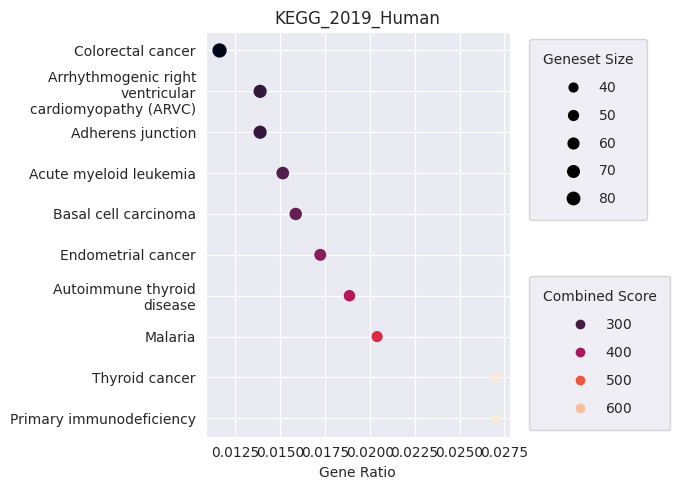

In [27]:
## 绘图
from Garfield.plot import niches_enrichment_barplot, niches_enrichment_dotplot

ax = niches_enrichment_dotplot(
        enrich_dict,
        niche='3',
        type="enrichr",  # 默认为 enrichr 类型
        figsize=(7, 5),
        n_enrichments=10,
        qval_cutoff=0.05,
        title="auto",
)

### 找 niche 差异基因 for all data

In [15]:
def extract_top_genes_spatial(
    adata,
    workdir,
    latent_cluster_key,
    n_top_markers=5,
    output_file="all_marker_genes_spatial_data.csv",
    use_normalized=False
):
    """
    提取 AnnData 对象中所有 marker 基因的表达数据、空间位置信息和 cluster 信息，并保存为 CSV 文件。

    Parameters:
    -----------
    adata : AnnData
        包含 rank_genes_groups 和空间信息的 AnnData 对象。
    workdir : str
        输出文件的保存目录。
    latent_cluster_key : str
        cluster 信息所在的 obs 键。
    output_file : str
        保存的 CSV 文件名。
    use_normalized : bool
        如果为 True，使用标准化后的数据 (.X)；否则使用 counts 层数据。

    Returns:
    --------
    None
    """
    import os
    import pandas as pd

    # 检查 rank_genes_groups 是否存在
    if "rank_genes_groups" not in adata.uns:
        raise ValueError("The AnnData object does not contain 'rank_genes_groups' in .uns.")

    # 提取所有 marker 基因
    ranked_genes = adata.uns['rank_genes_groups']
    marker_genes = set()  # 使用集合避免重复
    clusters = ranked_genes['names'].dtype.names  # 获取所有 cluster 名
    for cluster in clusters:
        top_genes = ranked_genes['names'][cluster][:n_top_markers]  # 获取Top n 基因名
        print(f'Top markers of cluster {cluster}: {top_genes}')
        marker_genes.update(top_genes)  # 添加当前 cluster 的 marker 基因

    marker_genes = list(marker_genes)  # 转换为列表

    # 提取表达数据
    if use_normalized:
        gene_expression = adata[:, marker_genes].X  # 标准化数据
    else:
        gene_expression = adata[:, marker_genes].layers['counts']  # counts 数据

    # 提取空间位置信息
    spatial_positions = adata.obsm['spatial']

    # 提取 cluster 信息
    clusters = adata.obs[latent_cluster_key]

    # 构建最终 DataFrame
    final_dataframe = pd.DataFrame(
        gene_expression.toarray() if hasattr(gene_expression, "toarray") else gene_expression,
        columns=marker_genes,
        index=adata.obs.index
    )
    final_dataframe['x'] = spatial_positions[:, 0]  # 添加 x 坐标
    final_dataframe['y'] = spatial_positions[:, 1]  # 添加 y 坐标
    final_dataframe['cluster'] = clusters.values  # 添加 cluster 信息

    # 保存为 CSV 文件
    os.makedirs(workdir, exist_ok=True)  # 确保工作目录存在
    final_dataframe.to_csv(os.path.join(workdir, output_file))
    print(f"Data saved to {os.path.join(workdir, output_file)}")


In [24]:
def extract_top_genes_spatial2(
    adata,
    workdir,
    latent_cluster_key,
    n_top_markers=5,
    diy_marker_list=None,
    output_file="all_marker_genes_spatial_data.csv",
    use_normalized=False,
    remove_mitochondrial=True,
    remove_red_blood_cells=True,
    species="human"  # species can be 'human' or 'mouse'
):
    """
    提取 AnnData 对象中所有 marker 基因的表达数据、空间位置信息和 cluster 信息，并保存为 CSV 文件。
    移除线粒体基因和红细胞相关基因。适配人类或小鼠数据。

    Parameters:
    -----------
    adata : AnnData
        包含 rank_genes_groups 和空间信息的 AnnData 对象。
    workdir : str
        输出文件的保存目录。
    latent_cluster_key : str
        cluster 信息所在的 obs 键。
    output_file : str
        保存的 CSV 文件名。
    use_normalized : bool
        如果为 True，使用标准化后的数据 (.X)；否则使用 counts 层数据。
    remove_mitochondrial : bool
        如果为 True，移除线粒体基因。
    remove_red_blood_cells : bool
        如果为 True，移除红细胞相关基因。
    species : str
        数据来源物种，"human" 或 "mouse"。

    Returns:
    --------
    None
    """
    import os
    import pandas as pd

    # 检查 rank_genes_groups 是否存在
    if "rank_genes_groups" not in adata.uns:
        raise ValueError("The AnnData object does not contain 'rank_genes_groups' in .uns.")

    # 提取所有 marker 基因
    ranked_genes = adata.uns['rank_genes_groups']
    marker_genes = set()  # 使用集合避免重复
    clusters = ranked_genes['names'].dtype.names  # 获取所有 cluster 名

    # 定义线粒体基因和红细胞基因的过滤列表
    mitochondrial_prefix = 'MT-' if species == "human" else 'mt-'
    red_blood_cell_genes = {
        "human": ["HBA1", "HBA2", "HBB", "HBG1", "HBG2", "HBD", "HBQ1", "HBS1", "RBC"],
        "mouse": ["Hba-a1", "Hba-a2", "Hbb-b1", "Hbb-b2", "Hbd", "Hbb", "Rbc"]
    }

    # 收集所有需要排除的基因
    excluded_genes = set()
    if remove_mitochondrial:
        excluded_genes.update({gene for gene in adata.var_names if gene.startswith(mitochondrial_prefix)})
    if remove_red_blood_cells:
        excluded_genes.update(red_blood_cell_genes.get(species, []))

    # 提取 marker 基因并排除不需要的基因
    cluster_marker_genes = {}  # 用来存储每个cluster的最终marker基因
    for cluster in clusters:
        top_genes = ranked_genes['names'][cluster][:n_top_markers]  # 获取Top n 基因
        current_marker_genes = set(top_genes)  # 当前 cluster 的 marker 基因

        # 排除不需要的基因
        current_marker_genes -= excluded_genes

        # 更新最终的marker基因集合
        cluster_marker_genes[cluster] = list(current_marker_genes)

        # 打印每个cluster的最终marker基因
        print(f"Cluster {cluster}: {list(current_marker_genes)}")

    # 汇总所有 cluster 的 marker 基因
    marker_genes = set([gene for genes in cluster_marker_genes.values() for gene in genes])

    # 提示输出
    print(f"Extracted {len(marker_genes)} total unique marker genes after filtering.")

    # 确保所有marker基因都在adata.var_names中
    marker_genes = [gene for gene in marker_genes if gene in adata.var_names]
    if len(marker_genes) == 0:
        raise ValueError("No valid marker genes found in the AnnData object.")

    ## 拓展现有的marker，增加人为定义的
    if diy_marker_list is not None:
        marker_genes.extend(diy_marker_list)

    # 提取表达数据
    if use_normalized:
        gene_expression = adata[:, marker_genes].X  # 使用标准化数据
    else:
        gene_expression = adata[:, marker_genes].layers['counts']  # counts 数据

    # 提取空间位置信息
    if 'spatial' not in adata.obsm:
        raise ValueError("Spatial information not found in adata.obsm.")
    spatial_positions = adata.obsm['spatial']

    # 提取 cluster 信息
    clusters = adata.obs[latent_cluster_key]

    # 构建最终 DataFrame
    final_dataframe = pd.DataFrame(
        gene_expression.toarray() if hasattr(gene_expression, "toarray") else gene_expression,
        columns=marker_genes,
        index=adata.obs.index
    )

    # 添加空间位置信息
    final_dataframe['x'] = spatial_positions[:, 0]  # 添加 x 坐标
    final_dataframe['y'] = spatial_positions[:, 1]  # 添加 y 坐标

    # 添加 cluster 信息
    final_dataframe['cluster'] = clusters

    # 输出最终的 CSV 文件
    final_dataframe.to_csv(os.path.join(workdir, output_file))

    print(f"Marker genes data saved to {os.path.join(workdir, output_file)}.")

In [16]:
model.adata.obs['latent_leiden_0.8'].value_counts()

latent_leiden_0.8
0     39414
1     33816
2     29583
3     27379
4     25503
5     23139
6     23101
7     20871
8     14712
9     11102
10    10264
11     9029
12     7899
13     6551
Name: count, dtype: int64

In [21]:
latent_leiden_resolution = 0.8
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"

# batch 1
tmp = model.adata.copy() # [model.adata.obs['replicates'].isin(['Rep_1']), :]
# tmp.obs_names = adata_batch1.obs_names
adata_new.obs[latent_cluster_key] = tmp.obs[latent_cluster_key]
sc.pp.normalize_total(adata_new, target_sum=1e4)
sc.pp.log1p(adata_new)
sc.tl.rank_genes_groups(adata_new, latent_cluster_key, method='wilcoxon')

In [22]:
df  = sc.get.rank_genes_groups_df(adata_batch1, group=None)
df = df.sort_values(by="scores", ascending=False)
df.to_csv(os.path.join(workdir, 'diff_niches_alldata.csv'), index=0, sep='\t')

In [23]:
## output res
extract_top_genes_spatial(
    adata_new,
    workdir,
    latent_cluster_key,
    n_top_markers=5,
    output_file="top_genes_spatial_data_alldata.csv",
    use_normalized=True
)

Top markers of cluster 0: ['LUM' 'POSTN' 'CCDC80' 'MMP2' 'PDGFRB']
Top markers of cluster 1: ['EPCAM' 'FOXA1' 'FASN' 'KRT7' 'ABCC11']
Top markers of cluster 2: ['FCER1G' 'FGL2' 'LYZ' 'CD4' 'CD68']
Top markers of cluster 3: ['IL7R' 'TRAC' 'CD3E' 'CXCR4' 'PTPRC']
Top markers of cluster 4: ['CD3E' 'CCL5' 'PTPRC' 'TRAC' 'CD8A']
Top markers of cluster 5: ['CAV1' 'PECAM1' 'CD93' 'AQP1' 'VWF']
Top markers of cluster 6: ['CEACAM6' 'GATA3' 'TACSTD2' 'CD9' 'MLPH']
Top markers of cluster 7: ['TACSTD2' 'KRT8' 'CEACAM6' 'CCND1' 'CDH1']
Top markers of cluster 8: ['TOP2A' 'EPCAM' 'CENPF' 'FASN' 'FOXA1']
Top markers of cluster 9: ['MYLK' 'KRT14' 'DST' 'KRT5' 'ACTA2']
Top markers of cluster 10: ['ERBB2' 'KRT7' 'KRT8' 'FOXA1' 'EPCAM']
Top markers of cluster 11: ['ITM2C' 'TENT5C' 'SLAMF7' 'MZB1' 'SEC11C']
Top markers of cluster 12: ['MS4A1' 'BANK1' 'CXCR4' 'SELL' 'PTPRC']
Top markers of cluster 13: ['KRT15' 'SFRP1' 'TACSTD2' 'KRT23' 'KRT6B']
Data saved to /pri_exthome/zhouwg/project/Garfield_benchmark/re

In [ ]:
## output res
extract_top_genes_spatial2(
    adata_new,
    workdir,
    latent_cluster_key,
    diy_marker_list = ['TCIM'],
    n_top_markers=10,
    output_file="top_genes_spatial_data_alldata2.csv",
    use_normalized=True,
    remove_mitochondrial=True,
    remove_red_blood_cells=True,
    species='human'
)

In [13]:
dataset_name

'xenium_human_breast'

In [25]:
latent_cluster_key = 'latent_leiden_0.8'
cell_type_key = 'Cluster'

adata_query = model.adata.copy()
adata_query

AnnData object with n_obs × n_vars = 282363 × 313
    obs: 'cell_id', 'batch', 'replicates', 'n_genes', 'latent_leiden_0.5', 'latent_leiden_0.4', 'latent_leiden_0.6', 'latent_leiden_0.7', 'latent_leiden_0.8', 'Cluster'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'batch_colors', 'garfield_latent', 'hvg', 'latent_leiden_0.4', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'latent_leiden_0.6', 'latent_leiden_0.7', 'latent_leiden_0.8', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'feat', 'garfield_latent', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivities', 'distances', 'garfield_latent_connectivities', 'garfield_latent_distances', 'spatial_connectivities'

In [37]:
import pandas as pd

def calculate_celltype_proportion(confusion_matrix, save_path=None, file_format='csv'):
    """
    计算每个niche中各个celltype的比例，并可选择保存结果。

    参数：
    - confusion_matrix (pd.DataFrame): 行是niches，列是celltypes的混淆矩阵。
    - save_path (str, optional): 保存结果的路径。如果为None，则不保存结果。
    - file_format (str, optional): 保存文件的格式，支持 'csv' 和 'xlsx'，默认为 'csv'。

    返回：
    - proportion_matrix (pd.DataFrame): 每个niche中各个celltype的比例矩阵。
    """
    # 计算每个niche的总数（行的总和）
    niche_totals = confusion_matrix.sum(axis=1)

    # 计算每个celltype在每个niche中的比例
    proportion_matrix = confusion_matrix.div(niche_totals, axis=0)

    # 如果指定了保存路径，保存结果
    if save_path:
        if file_format == 'csv':
            proportion_matrix.to_csv(save_path)
            print(f"结果已保存为 {save_path} (CSV 格式)")
        elif file_format == 'xlsx':
            proportion_matrix.to_excel(save_path)
            print(f"结果已保存为 {save_path} (Excel 格式)")
        else:
            print(f"不支持的文件格式 {file_format}，未保存结果")

    return proportion_matrix

In [38]:
# 调用函数并保存结果 replicated-1
tmp = adata_query[adata_query.obs['replicates'] == 'Rep_1'].copy()
df = tmp.obs[[latent_cluster_key, cell_type_key]].groupby([latent_cluster_key, cell_type_key]).size().unstack(fill_value=0)
proportion_matrix = calculate_celltype_proportion(confusion_matrix=df,
                                                  save_path=f'{workdir}/niche_prop_rep1.csv',
                                                  file_format='csv')
# 输出 df
df.to_csv(f'{workdir}/niche_rep1.csv')

# 打印比例矩阵
proportion_matrix

结果已保存为 /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_xenium_human_breast/niche_prop_rep1.csv (CSV 格式)


Cluster,B_Cells,CD4+_T_Cells,CD8+_T_Cells,DCIS_1,DCIS_2,Endothelial,IRF7+_DCs,Invasive_Tumor,LAMP3+_DCs,Macrophages_1,Macrophages_2,Mast_Cells,Myoepi_ACTA2+,Myoepi_KRT15+,Perivascular-Like,Prolif_Invasive_Tumor,Stromal,Stromal_&_T_Cell_Hybrid,T_Cell_&_Tumor_Hybrid,Unlabeled
latent_leiden_0.8,,,,,,,,,,,,,,,,,,,,
0,0.000153,0.000153,0.000000,0.000459,0.000306,0.000102,0.000153,0.000919,0.000102,0.000357,0.000000,0.001429,0.000817,0.000000,0.000153,0.000153,0.993721,0.000051,0.000000,0.000970
1,0.000088,0.000000,0.000000,0.000482,0.003288,0.000000,0.000132,0.947749,0.000000,0.002718,0.000000,0.000000,0.000044,0.000000,0.000044,0.002849,0.039846,0.000000,0.000044,0.002718
2,0.000244,0.000792,0.000549,0.002621,0.002256,0.000610,0.002073,0.007925,0.002743,0.538040,0.095160,0.003414,0.004938,0.000183,0.000183,0.000488,0.325287,0.000000,0.000061,0.012436
3,0.003736,0.502996,0.117825,0.000064,0.000129,0.006571,0.005154,0.001031,0.013206,0.044708,0.000387,0.001997,0.000387,0.000000,0.000902,0.000000,0.177092,0.025639,0.003285,0.094891
4,0.001078,0.026130,0.337666,0.002761,0.003502,0.002424,0.000404,0.014142,0.000471,0.049364,0.000337,0.000808,0.009967,0.003367,0.000067,0.000741,0.398141,0.013267,0.035019,0.100343
5,0.000305,0.002596,0.001909,0.000000,0.000458,0.667812,0.000458,0.010383,0.000305,0.007253,0.000763,0.000382,0.005573,0.000076,0.061918,0.000458,0.219346,0.000000,0.000229,0.019774
6,0.000000,0.000000,0.000000,0.897792,0.057276,0.000077,0.000000,0.028753,0.000000,0.000153,0.000000,0.000000,0.007591,0.001073,0.000000,0.000690,0.000537,0.000000,0.000000,0.006057
7,0.000000,0.000000,0.000000,0.030681,0.741906,0.000000,0.000000,0.118023,0.000077,0.000617,0.000000,0.000000,0.094897,0.000385,0.000000,0.004163,0.001233,0.000000,0.000077,0.007940
8,0.000000,0.000000,0.000000,0.000101,0.001624,0.000203,0.000000,0.624480,0.000000,0.001319,0.000000,0.000000,0.000000,0.000000,0.000000,0.358875,0.009337,0.000000,0.000000,0.004060


In [39]:
# 调用函数并保存结果 replicated-2
tmp = adata_query[adata_query.obs['replicates'] == 'Rep_2'].copy()
df = tmp.obs[[latent_cluster_key, cell_type_key]].groupby([latent_cluster_key, cell_type_key]).size().unstack(fill_value=0)
proportion_matrix = calculate_celltype_proportion(confusion_matrix=df,
                                                  save_path=f'{workdir}/niche_prop_rep2.csv',
                                                  file_format='csv')
# 输出 df
df.to_csv(f'{workdir}/niche_rep2.csv')

# 打印比例矩阵
proportion_matrix

结果已保存为 /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_xenium_human_breast/niche_prop_rep2.csv (CSV 格式)


Cluster,B_Cells,CD4+_T_Cells,CD8+_T_Cells,DCIS_1,DCIS_2,Endothelial,IRF7+_DCs,Invasive_Tumor,LAMP3+_DCs,Macrophages_1,Macrophages_2,Mast_Cells,Myoepi_ACTA2+,Myoepi_KRT15+,Perivascular-Like,Prolif_Invasive_Tumor,Stromal,Stromal_&_T_Cell_Hybrid,T_Cell_&_Tumor_Hybrid,Unlabeled
latent_leiden_0.8,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.000101,0.000353,0.001009,0.000151,0.000303,0.000404,0.000000,0.000050,0.000404,0.002169,0.000757,0.000000,0.000000,0.000000,0.993241,0.000000,0.000000,0.001059
1,0.000000,0.000182,0.000091,0.002636,0.000454,0.000091,0.000091,0.939653,0.000000,0.003908,0.000000,0.000091,0.000273,0.000182,0.000000,0.002454,0.048441,0.000000,0.000000,0.001454
2,0.000228,0.000379,0.000531,0.001973,0.002732,0.000607,0.001442,0.004477,0.001821,0.480917,0.115031,0.003415,0.005463,0.000228,0.000228,0.000228,0.368389,0.000000,0.000000,0.011913
3,0.002699,0.464828,0.116565,0.000253,0.000000,0.004217,0.005820,0.000337,0.012736,0.044450,0.000084,0.002446,0.000169,0.000000,0.000422,0.000000,0.212213,0.031208,0.001350,0.100202
4,0.001314,0.024404,0.326262,0.001408,0.005256,0.001690,0.000469,0.009292,0.000657,0.044678,0.000188,0.000657,0.009574,0.003191,0.000094,0.000375,0.445842,0.015675,0.021307,0.087667
5,0.000199,0.002191,0.001593,0.000100,0.000398,0.656010,0.000299,0.006374,0.000398,0.006274,0.001892,0.000697,0.005677,0.000000,0.053481,0.000000,0.250772,0.000000,0.000000,0.013644
6,0.000000,0.000000,0.000000,0.046327,0.909733,0.000000,0.000000,0.027637,0.000000,0.000199,0.000000,0.000099,0.007555,0.001789,0.000000,0.000696,0.000199,0.000000,0.000000,0.005766
7,0.000000,0.000127,0.000000,0.773642,0.027345,0.000000,0.000000,0.047474,0.000000,0.001013,0.000000,0.000000,0.133308,0.006203,0.000000,0.002026,0.002532,0.000000,0.000127,0.006203
8,0.000000,0.000206,0.000000,0.002470,0.000617,0.000000,0.000000,0.616999,0.000000,0.000617,0.000000,0.000000,0.000000,0.000000,0.000000,0.361803,0.014406,0.000000,0.000000,0.002881


<Axes: title={'center': 'Cluster'}, xlabel='UMAP1', ylabel='UMAP2'>

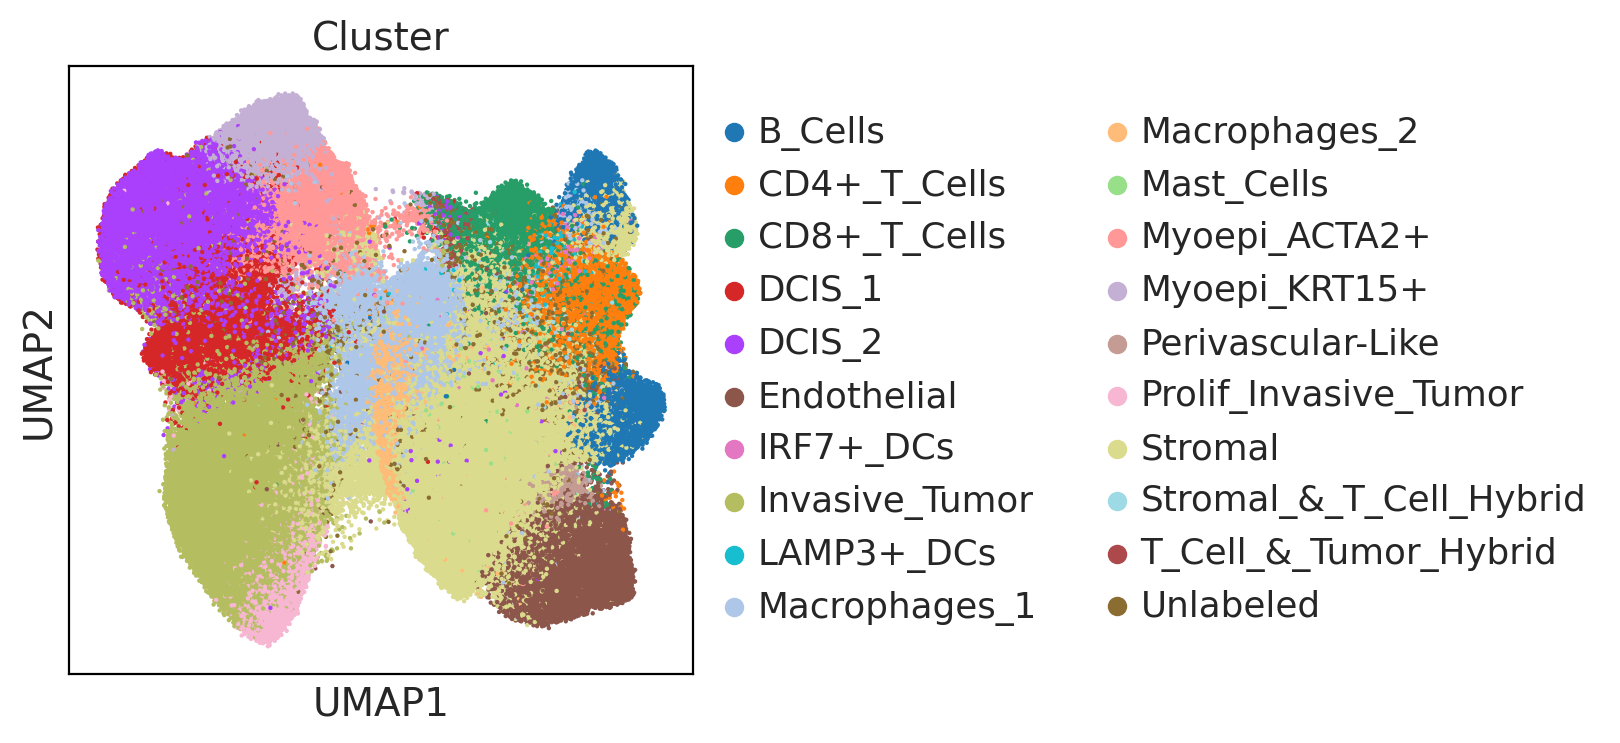

In [30]:
sc.settings.set_figure_params(dpi=100, facecolor='white')

sc.pl.umap(adata_query, color=['Cluster'],
           s=10, show=False, ncols=2, wspace=0.5)

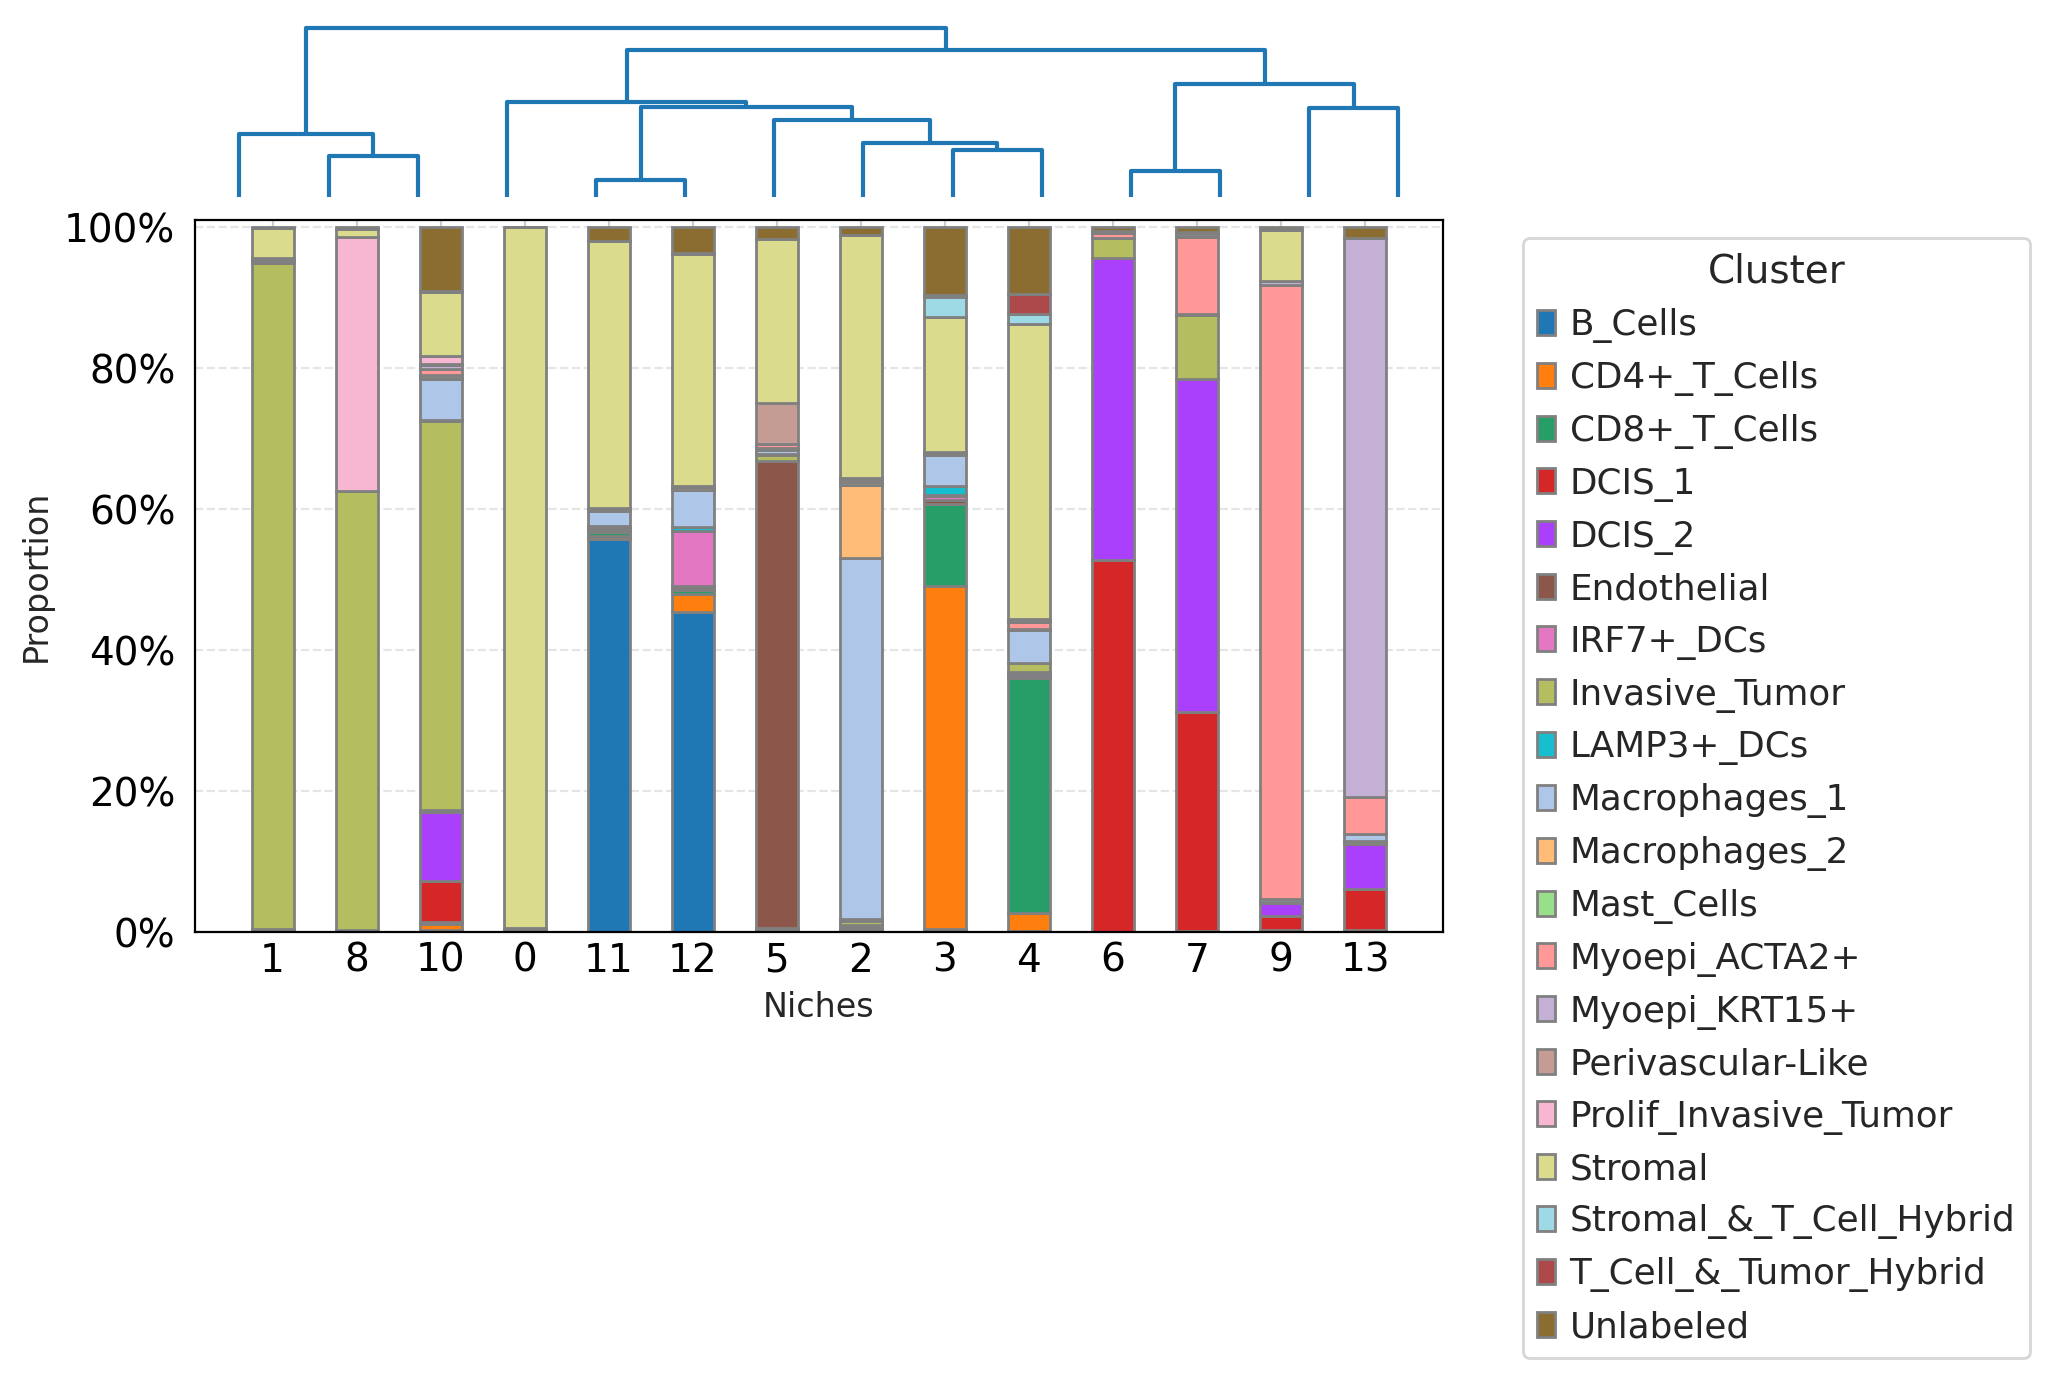

In [31]:
# scanpy结果画细胞分类百分比例图
import os
import scanpy as sc
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform

# 数据处理
df = adata_query.obs[[latent_cluster_key, cell_type_key]].groupby([latent_cluster_key, cell_type_key]).size().unstack(fill_value=0)
labels = df.index.tolist()  # 提取分类标签
results = df.to_dict(orient="list")  # 将数值结果转化为字典
category_names = list(results.keys())  # 提取类别（键-key）
data = np.array(list(results.values()))  # 提取数值（值-value）
category_colors = adata_query.uns["Cluster_colors"]  # 分类颜色

# 计算相似性并进行层次聚类
data_normalized = data / data.sum(axis=0)  # 正规化百分比
dist_matrix = squareform(pdist(data_normalized.T, metric="euclidean"))  # 计算样本之间的欧式距离
linkage_matrix = linkage(dist_matrix, method="ward")  # 使用层次聚类方法
dendro = dendrogram(linkage_matrix, labels=labels, no_plot=True)  # 获取聚类树的顺序

# 按聚类结果重新排序
ordered_labels = [labels[i] for i in dendro['leaves']]
ordered_data = data_normalized[:, dendro['leaves']]

# 创建主图和聚类树
fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 4], hspace=0.05)

# 绘制聚类树
ax_dendro = fig.add_subplot(gs[0, 0])
dendrogram(
    linkage_matrix,
    labels=ordered_labels,
    orientation="top",
    leaf_rotation=90,
    ax=ax_dendro,
    color_threshold=0,
)
ax_dendro.axis("off")  # 隐藏聚类树的坐标轴

# 绘制柱状图
ax_bar = fig.add_subplot(gs[1, 0])
starts = np.zeros(len(ordered_labels))  # 基准为 0

for i, (colname, color) in enumerate(zip(category_names, category_colors)):
    heights = ordered_data[i, :]  # 使用聚类排序后的数据
    ax_bar.bar(
        ordered_labels,
        heights,
        bottom=starts,
        width=0.5,
        label=colname,
        color=color,
        edgecolor="gray",
    )
    starts += heights  # 基于基准累加

# 美化柱状图
ax_bar.tick_params(axis="x", length=0)
ax_bar.set_xlabel("Niches", fontsize=12)
ax_bar.set_ylabel("Proportion", fontsize=12)
ax_bar.set_ylim(0, 1.01)
ax_bar.set_yticks(np.arange(0, 1.2, 0.2))
ax_bar.set_yticklabels([f"{int(i * 100)}%" for i in np.arange(0, 1.2, 0.2)])
ax_bar.grid(axis="y", alpha=0.5, ls="--")

# 添加图例，将图例移至图外
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# 保存和展示
plt.tight_layout()
# plt.savefig(os.path.join(workdir, "05.barplot_niche.pdf"), dpi=600)
# pic(os.path.join(workdir, "05.barplot_niche.pdf"))

In [32]:
def celltype_connectivity(adata, domain_key= 'Label',celltype_key = 'cluster', work_dir='./'):
    import squidpy as sq
    import random
    random.seed(42)

    sq.gr.spatial_neighbors(adata, n_neighs = 20, coord_type = 'generic')

    for label in adata.obs[domain_key].unique():
        # CCI
        adata_batch = adata[adata.obs[domain_key] == label].copy()
        # cell_types = adata_batch.obs[celltype_key].unique().tolist()
        sq.gr.interaction_matrix(adata_batch, cluster_key=celltype_key)
        CCI1=adata_batch.uns['{}_interactions'.format(celltype_key)].copy()
        CCI2=CCI1.T.copy()
        CCI=((CCI1+CCI2)/2).round()
        pairwise_connection=pd.DataFrame(CCI,
                                         index=adata_batch.obs[celltype_key].cat.categories,
                                         columns=adata_batch.obs[celltype_key].cat.categories)

        pairwise_connection[pairwise_connection<=0]=0

        # save data
        celltype_sum=pd.DataFrame(adata_batch.obs[celltype_key].value_counts())
        celltype_sub=celltype_sum[celltype_sum['count']>=10].copy()
        df=pairwise_connection.copy()
        min_x=df.min().min()
        max_x=df.max().max()
        for i in df.index:
            for j in df.columns:
                df.loc[i,j]=(df.loc[i,j]-min_x)/(max_x-min_x)
        df=df.loc[celltype_sum.index,celltype_sum.index].copy()
        df.to_csv(f'{work_dir}/BC_{label}_prob.csv')
        celltype_sub.to_csv(f'{work_dir}/BC_{label}_size.csv')

    return None

In [33]:
## 输出real的 CCI strength
celltype_key = "Cluster"
domain_key = "latent_leiden_0.8"

celltype_connectivity(adata=adata_query,
                      domain_key=domain_key,
                      celltype_key=celltype_key,
                      work_dir=workdir)

/home/zhouwg/anaconda3/envs/env_gf/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


### 输出结果供R绘图

In [35]:
### 输出celltype 和 空间位置数据供R绘图
# Extracting 'latent_leiden_0.3' and 'spatial' data
latent_leiden_data = adata_query.obs[cell_type_key]
niche_data = adata_query.obs[domain_key]
spatial_data = adata_query.obsm["spatial"]

# Creating a DataFrame for R visualization
output_df = pd.DataFrame({
    domain_key: latent_leiden_data,
    cell_type_key: latent_leiden_data,
    "spatial_X": spatial_data[:, 0],
    "spatial_Y": spatial_data[:, 1],
})

# Save to CSV
output_file = f"latent_niche_celltype_data_{dataset_name}.csv"
output_df.to_csv(os.path.join(workdir, output_file))

In [36]:
### 输出celltype 和 空间位置数据供R绘图
# Extracting 'latent_leiden_0.3' and 'spatial' data
latent_leiden_data = adata_query.obs[cell_type_key]
niche_data = adata_query.obs[domain_key]
spatial_data = adata_query.obsm["X_umap"]

# Creating a DataFrame for R visualization
output_df = pd.DataFrame({
    domain_key: latent_leiden_data,
    cell_type_key: latent_leiden_data,
    "umap_1": spatial_data[:, 0],
    "umap_2": spatial_data[:, 1],
})

# Save to CSV
output_file = f"latent_niche_celltype_umap_data_{dataset_name}.csv"
output_df.to_csv(os.path.join(workdir, output_file))

In [8]:
### 输出metadata
metadata=model.adata.obs.copy()

# Save to CSV
output_file = "metadata_breast_cancer.csv"
metadata.to_csv(os.path.join(workdir, output_file))

In [4]:
model.adata.obs['latent_leiden_0.8'].cat.categories

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13'],
      dtype='object')

In [6]:
## 输出 niche3 4的表达谱和meta信息
for i in ['3','4']:
    tmp=model.adata[(model.adata.obs['latent_leiden_0.8'].isin([i]))].copy()
    pd.DataFrame(tmp.transpose().X.toarray(),index=tmp.var.index,
                 columns=['cell_'+i for i in tmp.obs.index]).to_csv(os.path.join(workdir, 'BC_expr_niche{}.csv'.format(i)))
    metadata=tmp.obs.copy()
    metadata.index=['cell_'+i for i in metadata.index]
    metadata.to_csv(os.path.join(workdir, 'BC_metadata_niche{}.csv'.format(i)))

### Neighbors enrichment analysis

In [4]:
model.adata

AnnData object with n_obs × n_vars = 282363 × 313
    obs: 'cell_id', 'batch', 'replicates', 'n_genes', 'latent_leiden_0.5', 'latent_leiden_0.4', 'latent_leiden_0.6', 'latent_leiden_0.7', 'latent_leiden_0.8', 'Cluster'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'batch_colors', 'garfield_latent', 'hvg', 'latent_leiden_0.4', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'latent_leiden_0.6', 'latent_leiden_0.7', 'latent_leiden_0.8', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'feat', 'garfield_latent', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivities', 'distances', 'garfield_latent_connectivities', 'garfield_latent_distances', 'spatial_connectivities'

In [21]:
import pandas as pd
import numpy as np
import random
from joblib import Parallel, delayed
import squidpy as sq

def compute_cci_for_batch(adata_batch, celltype_key):
    """
    Helper function to compute the cell-cell interaction (CCI) matrix for a single batch.
    """
    # Ensure the cell type column is categorical
    adata_batch.obs[celltype_key] = adata_batch.obs[celltype_key].astype('category')

    # Get the unique cell types
    cell_types = adata_batch.obs[celltype_key].unique().tolist()

    # Compute the interaction matrix using squidpy
    sq.gr.interaction_matrix(adata_batch, cluster_key=celltype_key)
    CCI1 = adata_batch.uns[f'{celltype_key}_interactions'].copy()
    CCI2 = CCI1.T.copy()
    CCI = ((CCI1 + CCI2) / 2).round()

    # Create pairwise connectivity matrix
    pairwise_connection = pd.DataFrame(CCI,
                                       index=adata_batch.obs[celltype_key].cat.categories,
                                       columns=adata_batch.obs[celltype_key].cat.categories)

    pairwise_connection[pairwise_connection <= 0] = 0  # Filter out non-interacting pairs
    return pairwise_connection

def perform_permutation_test(adata, domain_key='Label', celltype_key='Cluster', n_permutations=1000, min_celltype_count=10, n_jobs=4, selected_domains=None):
    """
    Perform permutation-based statistical test for proximal cell-cell interactions.

    Parameters:
    - adata: AnnData object with spatial and cell type annotations.
    - domain_key: Key for the domain in adata.obs (e.g., tissue region).
    - celltype_key: Key for cell type information in adata.obs.
    - n_permutations: Number of permutations for the test (default 1000).
    - min_celltype_count: Minimum number of cells in each cell type to keep for analysis.
    - n_jobs: Number of jobs (cores) to use in parallel processing.
    - selected_domains: List of selected domain labels to compute. If None, all domains will be used.
    """
    # If no specific domains are selected, use all domains in the `domain_key` column
    if selected_domains is None:
        selected_domains = adata.obs[domain_key].unique()

    def process_domain(label):
        # Filter data for the current domain
        adata_batch = adata[adata.obs[domain_key] == label].copy()

        # Filter out cell types with fewer than `min_celltype_count` cells
        celltype_counts = adata_batch.obs[celltype_key].value_counts()
        valid_celltypes = celltype_counts[celltype_counts >= min_celltype_count].index
        adata_batch = adata_batch[adata_batch.obs[celltype_key].isin(valid_celltypes)]

        # Compute the cell-cell interaction matrix for the batch
        pairwise_connection = compute_cci_for_batch(adata_batch, celltype_key)

        # Calculate P-values by permutation
        p_values = []
        for cell_type1 in pairwise_connection.columns:
            for cell_type2 in pairwise_connection.index:
                # Get the real CCI value for this pair
                real_value = pairwise_connection.loc[cell_type1, cell_type2]

                # Perform permutation test
                permuted_values = []
                for _ in range(n_permutations):
                    # Randomly shuffle the cell type labels while keeping the spatial structure
                    adata_batch.obs[celltype_key] = random.sample(adata_batch.obs[celltype_key].tolist(), len(adata_batch.obs[celltype_key]))
                    permuted_connection = compute_cci_for_batch(adata_batch, celltype_key)
                    permuted_values.append(permuted_connection.loc[cell_type1, cell_type2])

                # Calculate the p-value as the proportion of permuted values greater than or equal to the real value
                p_value = np.mean(np.array(permuted_values) >= real_value)
                p_values.append((cell_type1, cell_type2, p_value))

        return label, p_values

    # Parallelize the domain processing using joblib
    results = Parallel(n_jobs=n_jobs)(delayed(process_domain)(label) for label in selected_domains)

    # Convert the results to a DataFrame
    p_values_df = pd.DataFrame(
        [(label, cell_type1, cell_type2, p_value) for label, p_values in results for cell_type1, cell_type2, p_value in p_values],
        columns=['Domain', 'CellType1', 'CellType2', 'PValue']
    )

    return p_values_df

/home/zhouwg/anaconda3/envs/env_gf/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [18]:
# 载入AnnData对象（示例数据）
import squidpy as sq
import scanpy as sc

# 假设adata是你加载的AnnData对象
# adata = sc.read("your_data.h5ad")

# 选择你要分析的域
selected_domains = ['3', '4']

tmp = model.adata.copy()
# 调用perform_permutation_test函数进行置换检验
p_values_df = perform_permutation_test(
    tmp,
    domain_key='latent_leiden_0.8',
    celltype_key='Cluster',
    n_permutations=1000,
    min_celltype_count=10,
    n_jobs=4,  # 使用4个核心
    selected_domains=selected_domains
)

# 查看P值的DataFrame
p_values_df

/home/zhouwg/anaconda3/envs/env_gf/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/home/zhouwg/anaconda3/envs/env_gf/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/tmp/ipykernel_3318589/1777016331.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/tmp/ipykernel_3318589/1777016331.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


,Domain,CellType1,CellType2,PValue
0,3,B_Cells,B_Cells,0.226
1,3,B_Cells,CD4+_T_Cells,0.000
2,3,B_Cells,CD8+_T_Cells,0.478
3,3,B_Cells,Endothelial,0.873
4,3,B_Cells,IRF7+_DCs,0.129
...,...,...,...,...
515,4,Unlabeled,Prolif_Invasive_Tumor,0.946
516,4,Unlabeled,Stromal,0.998
517,4,Unlabeled,Stromal_&_T_Cell_Hybrid,0.139
518,4,Unlabeled,T_Cell_&_Tumor_Hybrid,0.250


In [19]:
# 可以将结果保存到 CSV 文件以便后续分析
p_values_df.to_csv(os.path.join(workdir, 'CCI_permutation_niche3-4_results.csv'), index=False)

In [22]:
# 载入AnnData对象（示例数据）
import squidpy as sq
import scanpy as sc

# 假设adata是你加载的AnnData对象
# adata = sc.read("your_data.h5ad")

# 选择你要分析的域
selected_domains = ['12']

tmp = model.adata.copy()
# 调用perform_permutation_test函数进行置换检验
p_values_df = perform_permutation_test(
    tmp,
    domain_key='latent_leiden_0.8',
    celltype_key='Cluster',
    n_permutations=1000,
    min_celltype_count=10,
    n_jobs=4,  # 使用4个核心
    selected_domains=selected_domains
)

# 查看P值的DataFrame
p_values_df

/home/zhouwg/anaconda3/envs/env_gf/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/tmp/ipykernel_3979812/2432507497.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


,Domain,CellType1,CellType2,PValue
0,12,B_Cells,B_Cells,0.000
1,12,B_Cells,CD4+_T_Cells,0.000
2,12,B_Cells,CD8+_T_Cells,0.011
3,12,B_Cells,Endothelial,0.686
4,12,B_Cells,IRF7+_DCs,0.940
...,...,...,...,...
116,12,Unlabeled,Macrophages_1,0.490
117,12,Unlabeled,Macrophages_2,0.181
118,12,Unlabeled,Stromal,1.000
119,12,Unlabeled,Stromal_&_T_Cell_Hybrid,0.340


In [23]:
# 可以将结果保存到 CSV 文件以便后续分析
p_values_df.to_csv(os.path.join(workdir, 'CCI_permutation_niche12_results.csv'), index=False)